# Explore and cluster full-paper embeddings

This notebook loads the validated full-paper output of `Pipeline.ipynb`. It covers a hierarchical dendrogram and hierarchy-ordered cosine heatmap, nearest-neighbour inspection, PCA/UMAP projections and a comparison of K-means resolutions. Clustering and distance diagnostics use the **original embedding space**, not the two-dimensional projections.

Run with the **Python (batill)** kernel after downloading the completed embedding results. Run the setup and loading cells first. The hierarchical section can then run independently of PCA, UMAP and K-means. The five-cluster handoff cell explicitly exports the selected PDF-text assignments for `Topic analysis PDFs.ipynb`. Other text-clustering plots remain in memory. If analysis dependencies are missing, install the project's `analysis` extra in this environment.

The saved setup/loading, embedding-Leiden sweep, K-means sweep and five-cluster export outputs record the current selected PDF corpus. Projection and citation cells have separate execution prerequisites. The five-cluster topic notebook reads only the explicit PDF-text export.

The final section compares **direct-citation Leiden communities** with the text-based clusters on the same existing UMAP. It uses the reviewed citation graph and maps duplicate PDFs to unique works. The new citation section can run after the loading, UMAP and embedding-Leiden cells; K-means is needed only if chosen as the comparison method.

In [269]:
from pathlib import Path
import sys
import json
import html
import textwrap

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import trustworthiness

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src' / 'batill').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the batill project folder.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from batill.pipeline import validate_outputs
from batill.embedding import load_plans
from batill.selection import filter_analysis_corpus, deduplicate_pdf_corpus

OUTPUT_DIR = ROOT / 'outputs' / 'corpus_sections'
EXCLUSIONS_FILE = ROOT / 'configs' / 'analysis_exclusions.json'
RANDOM_STATE = 42
TOP_N = 5
from batill.pdf_topic_analysis import pdf_partition_input_id


## Load and align the papers

The embedding manifest is the authority for row order. Validation checks the vectors against the exact prepared inputs before analysis. PDF content hashes serve as stable paper keys; journal/year metadata and abstracts are not inferred or fabricated. Text previews and keyword summaries use the retained paper text, excluding the repeated model instruction and title prefix.

Wait for the embedding job to finish and run the download/install script before this cell. It does not perform inference or wait on the HPC.

**Scope selection:** after validating the full stored corpus, apply `configs/analysis_exclusions.json` by PDF hash to paper rows and embedding rows together. The loading cell displays the exclusion audit and retained count. The current list removes 24 of 318 papers. Original manifest Paper IDs are preserved, so gaps in Pxxx numbering are expected. Then `configs/pdf_duplicates.json` removes the two reviewed duplicate copies, leaving 292 canonical PDFs. Each uses its existing embedding; vectors are not averaged. Files and cached vectors are unchanged; all clustering, neighbours and projections below use the retained rows. To revise a decision, edit its `exclude` boolean and rerun from this cell. No other VC papers or small clusters are automatically excluded.


In [270]:
if not (OUTPUT_DIR / 'embeddings' / 'manifest.json').exists():
    raise FileNotFoundError('Download/install the completed corpus embeddings before running this notebook.')
print(validate_outputs(OUTPUT_DIR))
folder = OUTPUT_DIR / 'embeddings'
manifest = json.loads((folder / 'manifest.json').read_text())
plans = load_plans(OUTPUT_DIR / 'prepared')
by_input_id = {p['id']: p for p in plans}
with np.load(folder / 'embeddings.npz', allow_pickle=False) as saved:
    embeddings = saved['embeddings'].copy()
    keys = saved['pdf_sha256'].astype(str)

rows = []
for index, row in enumerate(manifest['rows']):
    plan = by_input_id[row['input_id']]
    prefix = f"Instruct: {plan['config']['instruction']}\nQuery: Title: {plan['title']}\n\n"
    assert all(s['text'].startswith(prefix) for s in plan['segments'])
    text = '\n\n'.join(s['text'][len(prefix):] for s in plan['segments'])
    rows.append({'Key': row['pdf_sha256'], 'Title': row['title'],
        'Paper ID': f'P{index + 1:03d}', 'source_filename': row['source_filename'],
        'embedding_text': text, 'text_preview': text[:1500],
        'segments': len(plan['segments']),
        'embedding_tokens': sum(s['token_count'] for s in plan['segments']),
        'input_status': 'Single input' if len(plan['segments']) == 1 else 'Multiple segments'})
papers = pd.DataFrame(rows)
assert papers['Key'].tolist() == keys.tolist() and papers['Key'].is_unique
papers, embeddings, exclusion_audit, analysis_selection = filter_analysis_corpus(
    papers, embeddings, EXCLUSIONS_FILE,
)
scope_papers = papers.copy()
scope_selection = analysis_selection.copy()
papers, embeddings, analysis_selection = deduplicate_pdf_corpus(
    papers, embeddings, EXCLUSIONS_FILE, analysis_selection)
print('Reviewed duplicate PDFs removed:', analysis_selection.get('duplicate_pdfs_removed', 0))
keys = papers['Key'].to_numpy(dtype=str)
print(f"Scope filter: {analysis_selection['loaded_papers']} loaded, "
      f"{analysis_selection['excluded_papers']} excluded, "
      f"{analysis_selection['retained_papers']} retained.")
print('Selection ID:', analysis_selection['selection_id'])
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100):
    display(exclusion_audit[['original_paper_id', 'title', 'source_filename',
                             'reason_category', 'status']])
if analysis_selection['unmatched_exclusions']:
    print('Some exclusions are absent from this loaded corpus; inspect the audit above.')
assert len(papers) >= 2
TOP_N = min(TOP_N, len(papers) - 1)
segmented = papers['segments'].to_numpy() > 1
print(f"Loaded {len(papers)} papers with {embeddings.shape[1]}-dimensional embeddings.")
print('Model:', manifest['config']['model'])
print('Papers represented by multiple segments:', int(segmented.sum()))

{'papers': 318, 'dimensions': 2560, 'corpus_id': '76aa8637573b046d7c3667caf170c7ccd4df631514790fde2eab1cbfe6eca056', 'matrix': '/Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/corpus_sections/embeddings/embeddings.npz'}
Reviewed duplicate PDFs removed: 2
Scope filter: 318 loaded, 24 excluded, 292 retained.
Selection ID: d4437a4c2460707a904d1e984814e9ac015a65212bf5498bf92764f7255980d5


,original_paper_id,title,source_filename,reason_category,status
0,P052,Who are the active investors? Evidence from Venture Capital,Bottazzi et al. - 2008 - Who are the active investors Evidence from venture capital.pdf,venture_capital_only,excluded
1,P074,"Internet Appendix to ""Activism and Takeovers'",Burkart und Lee - 2022 - Activism and Takeovers (Online Appendix).pdf,standalone_appendix,excluded
2,P098,APPENDIX,Colonnelli et al. - 2024 - Investing with the Government A Field Experiment in China (Online App...,standalone_appendix,excluded
3,P120,Investor Tax Credits and Entrepreneurship: Evidence from U.S. States,Denes et al. - 2023 - Investor Tax Credits and Entrepreneurship Evidence from U.S. States.pdf,scope_review,excluded
4,P142,Cost of experimentation and the evolution of venture capital-,Ewens et al. - 2018 - Cost of experimentation and the evolution of venture capital.pdf,venture_capital_only,excluded
5,P143,Venture capital contracts-,Ewens et al. - 2022 - Venture capital contracts.pdf,venture_capital_only,excluded
6,P146,Ewens und Rhodes-Kropf - 2015 - Is a VC Partnership Greater Than the Sum of Its Partners.pdf,Ewens und Rhodes-Kropf - 2015 - Is a VC Partnership Greater Than the Sum of Its Partners.pdf,venture_capital_only,excluded
7,P160,Made for each other: Perfect matching in venture capital markets,Fu et al. - 2019 - Made for each other - Perfect matching in venture capital markets.pdf,venture_capital_only,excluded
8,P173,Venture capital investment cycles: The impact of public markets,Gompers et al. - 2008 - Venture capital investment cycles - The impact of public markets.pdf,venture_capital_only,excluded
9,P174,Performance persistence in entrepreneurship,Gompers et al. - 2010 - Performance persistence in entrepreneurship.pdf,venture_capital_only,excluded


Loaded 292 papers with 2560-dimensional embeddings.
Model: Qwen/Qwen3-Embedding-4B
Papers represented by multiple segments: 290


## Hierarchical clustering: a readable cluster overview

Average linkage merges groups using the mean cosine distance between their papers, in the original embedding space. Set `MAX_HIERARCHY_CLUSTERS = 15` below to inspect **at most 15 clusters**. Tied merges at the cut height stay together, so the actual number can be smaller. This is an exploratory resolution, not an automatically selected number of economic themes.

All three views use the **same partition and C1, C2, … labels**, ordered along the hierarchy. IDs are labels, not rankings, and can change when the data or cut changes. The collapsed dendrogram preserves the original merge heights; it does not recluster cluster averages. `C3 (n=12)` always means cluster C3 contains 12 papers, including when n=1.


In [271]:
from batill.clustering import (
    cosine_hierarchy, cluster_hierarchy, plot_cluster_hierarchy,
    hierarchy_tables, plot_hierarchy,
)
import matplotlib.pyplot as plt

MAX_HIERARCHY_CLUSTERS = 15
REPRESENTATIVE_PAPERS = 3
CLUSTER_HEATMAP_LIMITS = None  # Auto-scale displayed values; e.g. (0.0, 1.0) for a fixed scale.

hierarchy = cosine_hierarchy(embeddings)
hierarchy_order = hierarchy['order']
hierarchy_clusters = cluster_hierarchy(hierarchy, max_clusters=MAX_HIERARCHY_CLUSTERS)
hierarchy_labels = hierarchy_clusters['labels']  # Aligned to original papers/embedding rows.
print(f"{len(papers)} papers in {len(hierarchy_clusters['members'])} clusters")
print('Cut cosine distance:', hierarchy_clusters['cut_distance'])


292 papers in 15 clusters
Cut cosine distance: 0.2728487240899616


### Cluster dendrogram and similarity heatmap

The dendrogram and both heatmap axes use exactly the same cluster order. The dendrogram shows how these groups merge at higher cosine distances; higher merges mean less similar groups.

Each off-diagonal cell averages the cosine similarities of **all paper pairs across the two clusters**. Each diagonal cell averages distinct paper pairs **within that cluster**. A singleton's diagonal is undefined and shown as a grey dash, not a perfect similarity of 1. Values are similarities, not probabilities or significance levels.

Look for within-cluster values higher than cross-cluster values. High off-diagonal similarities identify groups that overlap under this representation. The default colour range adapts to the displayed values to make differences visible; inspect the numbers and colourbar because small differences can look large. Use identical explicit colour limits when comparing runs.


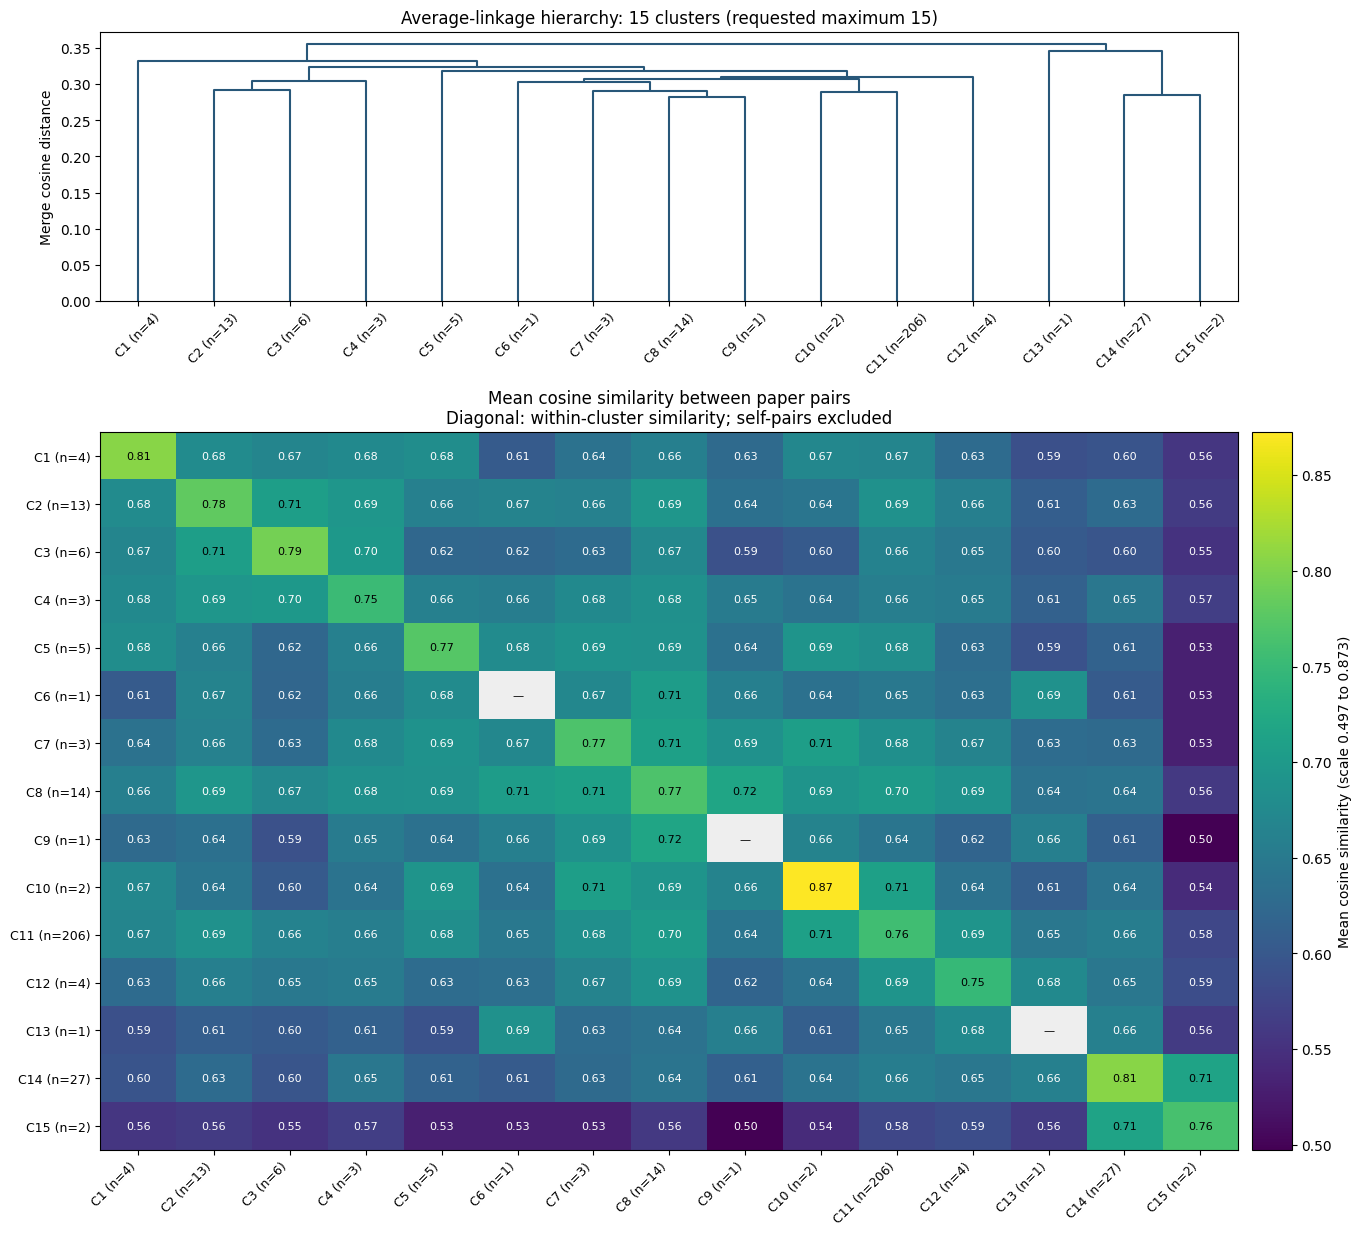

In [272]:
hierarchy_figure, hierarchy_axes = plot_cluster_hierarchy(
    hierarchy_clusters, color_limits=CLUSTER_HEATMAP_LIMITS,
)
plt.show()


### Cluster sizes and representative papers

Representatives have the highest mean cosine similarity to the other papers in their own cluster. They help explain its centre, but do not describe every member or automatically name its economic theme. Inspect the full membership when a group looks mixed. Titles are the extracted titles; known title errors still need correction.


In [273]:
hierarchy_summary, hierarchy_papers = hierarchy_tables(
    hierarchy, hierarchy_clusters, papers, representatives=REPRESENTATIVE_PAPERS,
)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(hierarchy_summary.style.format(
        {'Within-cluster similarity': '{:.3f}'}, na_rep='—', escape='html',
    ).set_properties(subset=['Representative papers'], **{'white-space': 'pre-wrap'}))


,Cluster,Papers,Within-cluster similarity,Representative papers
0,C1,4,0.807,P310: The Journal of Finance - 2011 - SHIVDASANI - Did Structured Credit Fuel the LBO Boom.pdf P005: Structure and Determinants of Financial Covenants in Leveraged Buyouts* P133: Leveraged buyouts and bond credit spreads-
1,C2,13,0.781,P182: Strategic and Financial Bidders in Takeover Auctions P049: Do private equity consortiums facilitate collusion in takeover bidding?☆ P031: Why do private acquirers pay so little compared to public acquirers?
2,C3,6,0.794,"P300: Corporate ownership structure and performance P224: Kaplan - 1989 - The Effects of Management Buyouts on Operating Performance and Value.pdf P019: Event risk, covenants, and bondholder returns in leveraged buyouts*"
3,C4,3,0.752,P121: Organizational form and the consequences of high1 leveraged transactions Kroger's recapitalization a P115: Dann - 1993 - Highly Leveraged Transactions and Managerial Discretion over Investment Policy An Overview.pdf P087: Capital Structure and Product-Market Competition: Empirical Evidence from the Supermarket Industry
4,C5,5,0.773,"P190: Dynamic Contracting with Intermediation: Operational, Governance, and Financial Engineering P167: Investment under Uncertainty, Heterogeneous Beliefs, and Agency Conflicts P132: Short-term termination without deterring long-term investment: A theory of debt and buyouts"
5,C6,1,—,P257: The Incredible Shrinking Stock Market: On the Political Economy Consequences of Excessive Delistings
6,C7,3,0.768,P314: How Are U.S. Family Firms Controlled? P007: The rise of dual-class stock IPOs∗ P089: Family ownership and R&D investment: the moderating role of banks and private equity
7,C8,14,0.767,P018: Lemons or Cherries? Growth Opportunities and Market Temptations in Going Public and Private P265: Financial Visibility and the Decision to Go Private P043: Why Do Firms Use Private Equity to Opt Out of Public Markets?
8,C9,1,—,P054: Company Websites: A New Measure of Disclosure
9,C10,2,0.873,P035: The economics of small business ®nance: The roles of private equity and debt markets in the ®nancial growth cycle P151: New resources and new ideas: Private equity for small businesses 1


### Copyable report for manual outlier review

The cell below prints plain text that you can select and copy. It lists **all titles for clusters of 1–2 papers**, and **three central representatives plus the full paper count for clusters of 3 or more**. It deliberately recomputes a three-representative summary regardless of the display setting above.

Small clusters that merge late are candidates for inspection, not automatic outliers. Check whether their papers concern a valid niche topic, whether the text/title extraction is correct, and whether they fit the scope of the private-equity map. Cluster size depends on the selected cut. Do not remove an in-scope paper solely to make the plot cleaner; record a substantive reason for any eventual exclusion. This cell excludes nothing and does not send the report to anyone.


In [274]:
from batill.clustering import cluster_review_report

review_summary, review_membership = hierarchy_tables(
    hierarchy, hierarchy_clusters, papers, representatives=3,
)
hierarchy_review_text = cluster_review_report(review_summary, review_membership)
print(f"Dataset: {OUTPUT_DIR}")
print(f"Requested maximum clusters: {MAX_HIERARCHY_CLUSTERS}")
print()
print(hierarchy_review_text)


Dataset: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/corpus_sections
Requested maximum clusters: 15

HIERARCHICAL CLUSTER REVIEW
Small clusters are review candidates, not confirmed outliers.
Titles are extracted metadata and may need correction.

C1 — 4 paper(s) — 3 representative papers
  - P310: The Journal of Finance - 2011 - SHIVDASANI - Did Structured Credit Fuel the LBO Boom.pdf
  - P005: Structure and Determinants of Financial Covenants in Leveraged Buyouts*
  - P133: Leveraged buyouts and bond credit spreads-

C2 — 13 paper(s) — 3 representative papers
  - P182: Strategic and Financial Bidders in Takeover Auctions
  - P049: Do private equity consortiums facilitate collusion in takeover bidding?☆
  - P031: Why do private acquirers pay so little compared to public acquirers?

C3 — 6 paper(s) — 3 representative papers
  - P300: Corporate ownership structure and performance
  - P224: Kaplan - 1989 - The Effects of Management Buyouts on Operating Perfo

In [275]:
CLUSTER_TO_INSPECT = 'C1'  # Choose any cluster ID from the summary.
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(hierarchy_papers.loc[hierarchy_papers['Cluster'] == CLUSTER_TO_INSPECT])


,Cluster,Paper ID,Key,Title,source_filename,segments
0,C1,P255,ee36a2f6831947ed29c0d4122ee7ac241b7a4b38e2d1d1d7a801910b501d0cf9,Syndicated loan spreads and the composition of the syndicate,Lim et al. - 2014 - Syndicated loan spreads and the composition of the syndicate.pdf,8
1,C1,P005,2a21b697e4f775b6651ffcbee7ea664921c6067a5c42324f6e133cb80f7e434f,Structure and Determinants of Financial Covenants in Leveraged Buyouts*,Achleitner et al. - 2012 - Structure and Determinants of Financial Covenants in Leveraged Buyouts.pdf,5
2,C1,P310,31a96f9af497b290b3886360a353c539f039d01a691b211f9570ecfbb630d63d,The Journal of Finance - 2011 - SHIVDASANI - Did Structured Credit Fuel the LBO Boom.pdf,The Journal of Finance - 2011 - SHIVDASANI - Did Structured Credit Fuel the LBO Boom.pdf,7
3,C1,P133,c98e7915cc16b32e9fa717b08c2e5e09cd7fff7df36aae6d02a614a8665002fd,Leveraged buyouts and bond credit spreads-,Eisenthal-Berkovitz et al. - 2020 - Leveraged buyouts and bond credit spreads.pdf,7


### Optional paper-level detail

The cluster overview is the default. Enable the view below only to inspect individual papers in full hierarchy order. This detailed heatmap is not aggregated; its P001-style labels are paper IDs. No figures, labels or tables are saved automatically.


In [276]:
SHOW_PAPER_LEVEL_HEATMAP = False
if SHOW_PAPER_LEVEL_HEATMAP:
    detail_figure, detail_axes = plot_hierarchy(
        hierarchy, papers['Paper ID'].to_numpy(),
        cut_distance=hierarchy_clusters['cut_distance'],
        color_limits=(-1.0, 1.0), max_tick_labels=35,
    )
    plt.show()


## 1. Inspect nearest neighbours

Cosine similarity measures proximity between embedding directions; it is not a probability. Inspect whether neighbours share a research question, mechanism, method, or setting. Broad vocabulary alone is weaker evidence.

The function below excludes the query paper itself. Start with five reproducibly sampled papers, then search for papers you know well and query them by `Key`.


In [277]:
similarities = cosine_similarity(embeddings)
key_to_row = {key: i for i, key in enumerate(keys)}

def nearest_papers(paper_key, top_n=TOP_N):
    if paper_key not in key_to_row:
        raise KeyError(f"Unknown paper key: {paper_key}")
    if not isinstance(top_n, int) or not 1 <= top_n < len(papers):
        raise ValueError(f"top_n must be between 1 and {len(papers) - 1}.")
    query_row = key_to_row[paper_key]
    scores = similarities[query_row].copy()
    scores[query_row] = -np.inf
    rows = np.argsort(-scores, kind="stable")[:top_n]
    result = papers.iloc[rows][[
        "Key", "Title", "source_filename", "input_status", "text_preview"
    ]].copy()
    result.insert(0, "rank", np.arange(1, len(rows) + 1))
    result.insert(1, "cosine_similarity", scores[rows])
    return result.reset_index(drop=True)

def inspect_paper(paper_key, top_n=TOP_N, show_text=False):
    query = papers.iloc[key_to_row[paper_key]]
    print(f"{query['Key']}: {query['Title']}")
    print(f"{query['source_filename']} | {query['input_status']}")
    if show_text:
        print("\nQuery text preview:", query["text_preview"], "\n")
    neighbours = nearest_papers(paper_key, top_n)
    visible = neighbours if show_text else neighbours.drop(columns="text_preview")
    with pd.option_context("display.max_colwidth", None):
        display(visible.style.format({"cosine_similarity": "{:.3f}"}))
    return neighbours

sample_keys = np.random.default_rng(RANDOM_STATE).choice(keys, size=min(5, len(keys)), replace=False)
for paper_key in sample_keys:
    inspect_paper(paper_key)
    print()


d92e3f0924b126ded419dd80c97cdba34102973ea960f386e456784e0d32769a: Risk and Expected Returns of Private Equity Investments: Evidence Based on Market Prices
Kräussl und Pollet - 2015 - Risk and Expected Returns of Private Equity Investments Evidence Based on Market Prices.pdf | Multiple segments


,rank,cosine_similarity,Key,Title,source_filename,input_status
0,1,0.930,c1c30476ef0afb70fe37a5b3c52239fa322ff9f7422796d2cc5a1fa252796188,Boyer et al. - 2023 - Discount-Rate Risk in Private Equity Evidence from Secondary Market Transactions.pdf,Boyer et al. - 2023 - Discount-Rate Risk in Private Equity Evidence from Secondary Market Transactions.pdf,Multiple segments
1,2,0.912,1cc25d3a982fd554bb1f4218a91b0d3068087499e1871bba16b88d7b833eb1f9,Estimating Private Equity Returns from Limited Partner Cash Flows,Ang et al. - 2018 - Estimating Private Equity Returns from Limited Partner Cash Flows.pdf,Multiple segments
2,3,0.907,f525b8e2374ef3dd622aa2663d6602c6689e03d086dac7ae9ddde881eae0d8df,A New Method to Estimate Risk and Return of Nontraded Assets from Cash Flows: The Case of Private Equity Funds,Driessen et al. - 2012 - A New Method to Estimate Risk and Return of Nontraded Assets from Cash Flows The Case of Private Equity Funds.pdf,Multiple segments
3,4,0.906,08f9611869a310a8aa1bba83393b0ced538f5c142ff0a3e47252776a939436af,Evaluating Private Equity performance using Stochastic Discount Factors∗,Gredil et al. - 2020 - Evaluating Private Equity performance using Stochastic Discount Factors.pdf,Multiple segments
4,5,0.905,9c828babf9fdb003789d04899b397757876dc15bb424fea62967aa45253e3a73,Gredil et al. - 2025 - Diversifying Private Equity.pdf,Gredil et al. - 2025 - Diversifying Private Equity.pdf,Multiple segments



89043e0fdc0f8230331194cfa8b4ecca9bcbeb3bc92cb1dc0f4550b5a1922f22: Short-term termination without deterring long-term investment: A theory of debt and buyouts
Edmans - 2011 - Short-term termination without deterring long-term investment - A theory of debt and buyouts.pdf | Multiple segments


,rank,cosine_similarity,Key,Title,source_filename,input_status
0,1,0.846,3f74a7fd0faf2cb11a02d8a2283acf52485f325e9d2cbc696896929c5f70c22d,The structure of debt and active equity investors: The case of the buyout specialistq,Cotter und Peck - 2001 - The Structure of Debt and Active Equity Investors The Case of the Buyout Specialist.pdf,Multiple segments
1,2,0.837,8f11ebd6399fc24ccf06c8e7a32d80e55c87c50889521cc00e8833476ded9723,The Structure of Leveraged Buyouts and the Free-Rider Problem,Burkart et al. - 2026 - The Structure of Leveraged Buyouts and the Free-Rider Problem.pdf,Multiple segments
2,3,0.825,c602e64ec46fdce5a09ab2776cc8a157c47a860fea78cd3a9306d3c779300392,Institutional Liquidity Needs and the Structure of Monitored Finance,Winton - 2003 - Institutional Liquidity Needs and the Structure of Monitored Finance.pdf,Multiple segments
3,4,0.824,741967ca9a4eb2faed548028285e9e254e8a77147037db3bbeaf102a76a89919,Why Are Buyouts Levered? The Financial Structure of Private Equity Funds,Axelson et al. - 2009 - Why Are Buyouts Levered The Financial Structure of Private Equity Funds.pdf,Multiple segments
4,5,0.820,d4c84438f47f1fc5d8b15d855605f85a54ccb687b74782fcfd2135023c258e5e,A theory of LBO activity based on repeated debt-equity conflicts,Malenko und Malenko - 2015 - A theory of LBO activity based on repeated debt-equity conflicts.pdf,Multiple segments



1bca26d253979edf7877292340be47e6cb50dd3c2c6f649cacd02f3d578a5d01: Holthausen und Larcker - 1998 - The financial performance of reverse leveraged buyouts [Journal of Financial Economics 42 (1996) 293.pdf
Holthausen und Larcker - 1998 - The financial performance of reverse leveraged buyouts [Journal of Financial Economics 42 (1996) 293.pdf | Single input


,rank,cosine_similarity,Key,Title,source_filename,input_status
0,1,0.920,e1492089e8ba5bb0cee09500f571303eb1038823959fd7c377e18d52474c1963,The financial performance of reverse leveraged buyouts,Holthausen und Larcker - 1996 - The financial performance of reverse leveraged buyouts.pdf,Multiple segments
1,2,0.890,4622cc4051ede1b6af07f5ecbfb4e28eea41a1aab1aed73879fd8ff5f949021d,Consequences of leveraged buyouts,Palepu - 1990 - Consequences of leveraged buyouts.pdf,Multiple segments
2,3,0.862,78fe35dd3d04023742f5c68c11e759bab9fbe90e119cfa8d07f12983c119035f,On the Heterogeneity of Leveraged Going Private Transactions,Halpern et al. - 1999 - On the Heterogeneity of Leveraged Going Private Transactions.pdf,Multiple segments
3,4,0.859,78ed0afcfd07724f26d3b249e20d97558e24c552d1137c441a77b049f1176de3,The staying power of leveraged buyouts*,Kaplan - 1991 - The staying power of leveraged buyouts.pdf,Multiple segments
4,5,0.855,89d9fdc9492be9353bb0764642cd8687279e51e685b57876c57d2cf28a47195e,Secondary Buyouts: Operating Performance and Investment Determinants,Financial Management - 2015 - Bonini - Secondary Buyouts Operating Performance and Investment Determinants.pdf,Multiple segments



9bd4201216c6d2c29943a70b3e5f060dcb78b23f57424c1dd3aac918fcfdacc7: Journal of Accounting and Economics
Baik - 2026 - Earnings management in private equity portfolio firms during fundraising.pdf | Multiple segments


,rank,cosine_similarity,Key,Title,source_filename,input_status
0,1,0.881,4cf9ccd4e03e0c633517c00f503e4cc3a899150c524a2ccb2faa82473bb7b91a,Raising Funds on Performance: Are Private Equity Returns Too Good to Be True?,Hüther - 2018 - Raising Funds on Performance Are Private Equity Returns Too Good to Be True.pdf,Multiple segments
1,2,0.880,338dd6ffdff79306aca2acd3b5e58e39f5a3c96eac5997cab0a612b6b2b68e09,Do private equity funds manipulate reported returns?-,Brown et al. - 2019 - Do private equity funds manipulate reported returns.pdf,Multiple segments
2,3,0.864,2e1d09e815b5e01e2bb758d2cfe0bff0bbd2253241efff4ac0f0411dca7c8f07,Does Mandatory Disclosure Matter for Private Equity Funds?,Jiang et al. - 2025 - Does Mandatory Disclosure Matter for Private Equity Funds.pdf,Multiple segments
3,4,0.862,b42c6be3cb6ae95f9e4430081838e6aa97f4c2448c8cb9ade2fdef0aa16c9f9f,Interim fund performance and fundraising in private equity✩,Barber und Yasuda - 2017 - Interim fund performance and fundraising in private equity.pdf,Multiple segments
4,5,0.856,060daaac8bdff5437b007a9d5b41e738e05c0cd3c23d74357ab7c279058483a6,Private equity returns and disclosure around the world,Cumming und Walz - 2010 - Private equity returns and disclosure around the world.pdf,Multiple segments



b9b50f74a737075e4fbe1ebefcdfa97ea0e0727e03ecf1ee49567a9eab685002: Edgerton - 2012 - Agency Problems in Public Firms Evidence from Corporate Jets in Leveraged Buyouts.pdf
Edgerton - 2012 - Agency Problems in Public Firms Evidence from Corporate Jets in Leveraged Buyouts.pdf | Multiple segments


,rank,cosine_similarity,Key,Title,source_filename,input_status
0,1,0.825,78fe35dd3d04023742f5c68c11e759bab9fbe90e119cfa8d07f12983c119035f,On the Heterogeneity of Leveraged Going Private Transactions,Halpern et al. - 1999 - On the Heterogeneity of Leveraged Going Private Transactions.pdf,Multiple segments
1,2,0.812,3e341022dc3254fc048cbe2c1f4e925bb939c4ab2a03278f0ff3616c58d4f698,CEO Turnover in Private Equity Sponsored Leveraged Buyoutscorg_834 195..209,Corporate Governance - 2010 - Gong - CEO Turnover in Private Equity Sponsored Leveraged Buyouts.pdf,Multiple segments
2,3,0.808,6c82409f544f78bc049343762ba99aff55b73ad93b2be2b7010e7255ae075b1d,CEO contract design: How do strong principals do it?,Cronqvist und Fahlenbrach - 2013 - CEO contract design - How do strong principals do it.pdf,Multiple segments
3,4,0.807,17a47344a8619e537614c194328d90f553ba5a363dad58dcc489688209f46ddb,Does going private add value through operating improvements?,Ayash und Schütt - 2016 - Does going private add value through operating improvements.pdf,Multiple segments
4,5,0.807,ab1e3a2c8d690a65569e68aaa835ad8795bea853b934f8e6f01917b2deadbe50,The evolution of capital structure and operating performance after leveraged buyouts: Evidence from U.S. corporate tax returns,Cohn et al. - 2014 - The evolution of capital structure and operating performance after leveraged buyouts Evidence from.pdf,Multiple segments


## Leiden: communities in a weighted similarity graph

Each paper is a node. We connect it to its nearest neighbours using cosine similarity in the **original embedding space**, not PCA or UMAP. The default undirected **union kNN** graph includes an edge if either paper selects the other. `LEIDEN_MUTUAL = True` requires both directions and can fragment the graph more strongly. Edge weights are the original positive cosine similarities; self-edges, zero and negative similarities are omitted, not shifted into positive weights. All papers remain nodes.

Leiden optimizes the weighted **RB configuration objective**, with a resolution parameter. Higher resolution generally favours smaller communities; it is not a requested cluster count. We inspect resolutions that yield **2–15 communities**, without forcing or silently merging groups. Graph sparsity, threshold and resolution all affect the answer. Disconnected components and isolated papers can prevent a useful small partition.

Install dependencies once in the selected kernel if needed: `%pip install igraph leidenalg`. The implementation is in `src/batill/graph_clustering.py`. These cells require only setup/loading above and do not require hierarchical clustering to have run. [Leiden API and objective documentation](https://leidenalg.readthedocs.io/en/stable/reference.html).


In [280]:
from batill.graph_clustering import similarity_graph, leiden_sweep, leiden_tables

LEIDEN_NEIGHBOURS = 15
LEIDEN_MIN_SIMILARITY = 0.0  # Keep only weights strictly above this threshold.
LEIDEN_MUTUAL = False
# Restored PDF grid: 0.10 to 1.20 in steps of 0.05 (1.25 is excluded).
LEIDEN_RESOLUTIONS = list(np.arange(0.1,1.25,0.05))
SELECTED_LEIDEN_RESOLUTION = 0.95  # Shared default for inspection, plots and export.
LEIDEN_SEEDS = [42, 43, 44]
LEIDEN_MAX_CLUSTERS = 15

leiden_fit_input_id = pdf_partition_input_id(papers.Key, embeddings)
leiden_graph = similarity_graph(
    embeddings, neighbours=LEIDEN_NEIGHBOURS,
    min_similarity=LEIDEN_MIN_SIMILARITY, mutual=LEIDEN_MUTUAL,
)
display(pd.DataFrame([leiden_graph['diagnostics']]))
print('Effective neighbours per paper before symmetrizing:', leiden_graph['neighbours'])
if leiden_graph['diagnostics']['isolated_papers']:
    print('Some papers have no edges. Inspect them; they are retained, not dropped.')
if leiden_graph['diagnostics']['components'] > LEIDEN_MAX_CLUSTERS:
    print('More disconnected components than the target maximum. Review graph construction first.')


,papers,edges,components,isolated_papers,min_degree,median_degree,max_degree
0,292,3319,1,0,15,19.0,75


Effective neighbours per paper before symmetrizing: 15


### Resolution, cluster sizes and stability

Each resolution is run with three seeds. The highest-objective run **within that resolution** supplies the reported partition; objectives are not ranked across resolutions. ARI reports seed agreement on this fixed graph (1 means identical partitions), not scientific validity. Cosine silhouette uses original paper distances, including pairs that have no graph edge. It is undefined for a single cluster or all-singleton partition.

Review the complete table and the 2–15-community candidates. Singleton counts and very large groups are useful warnings. If none fit the target, change the resolution range or graph settings explicitly. No resolution is automatically accepted as the final thesis partition.


,resolution,clusters,within_target,smallest,largest,singletons,cosine_silhouette,seed_stability_ARI,selected_seed
0,0.10,2,True,29,263,0,0.253263,1.000000,42
1,0.15,2,True,29,263,0,0.253263,1.000000,42
2,0.20,2,True,29,263,0,0.253263,1.000000,42
3,0.25,3,True,29,150,0,0.197421,0.387699,44
4,0.30,3,True,29,150,0,0.197421,0.743104,44
5,0.35,3,True,29,150,0,0.197421,0.749288,42
6,0.40,3,True,29,150,0,0.197421,0.749288,42
7,0.45,3,True,29,150,0,0.197421,0.934247,42
8,0.50,3,True,29,150,0,0.197421,0.934247,42
9,0.55,4,True,29,108,0,0.181525,0.733784,42


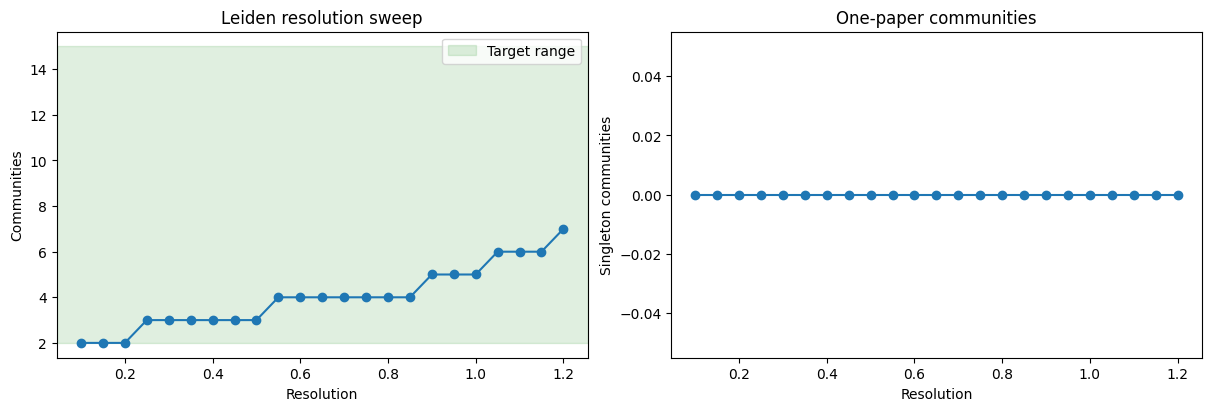

In [281]:
leiden_diagnostics, leiden_results = leiden_sweep(
    leiden_graph, LEIDEN_RESOLUTIONS, seeds=LEIDEN_SEEDS,
    max_clusters=LEIDEN_MAX_CLUSTERS,
)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(leiden_diagnostics)
leiden_candidates = leiden_diagnostics.loc[leiden_diagnostics['within_target']]
#print('Candidates within the requested cluster-count range:')
#display(leiden_candidates)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
axes[0].plot(leiden_diagnostics['resolution'], leiden_diagnostics['clusters'], 'o-')
axes[0].axhspan(2, LEIDEN_MAX_CLUSTERS, alpha=.12, color='green', label='Target range')
axes[0].set(xlabel='Resolution', ylabel='Communities', title='Leiden resolution sweep')
axes[0].legend()
axes[1].plot(leiden_diagnostics['resolution'], leiden_diagnostics['singletons'], 'o-')
axes[1].set(xlabel='Resolution', ylabel='Singleton communities', title='One-paper communities')
plt.show()


### Inspect a selected resolution

Set `LEIDEN_INSPECT_RESOLUTION` to a value from the sweep. The default 0.95 is the five-community partition exported for PDF topic interpretation below. L1, L2, … identify Leiden communities and have no relationship to C1, C2, … from the hierarchy. Representatives are the members most similar on average to the other papers in their community. Known extracted-title errors still apply.


,Cluster,Papers,Within-cluster similarity,Representative papers
0,L1,73,0.768,"P214: Private equity: A review and synthesisijmr_264 361..380 P003: Corporate Governance and Value Creation: Evidence from Private Equity P213: The Impact of Private Equity on Management Practices in European Buy-outs: Short-termism, Anglo-Saxon, or Host Country Effects?"
1,L2,62,0.760,P281: Consequences of leveraged buyouts P191: Guo et al. - 2011 - Do Buyouts (Still) Create Value.pdf P104: The structure of debt and active equity investors: The case of the buyout specialistq
2,L3,31,0.727,P018: Lemons or Cherries? Growth Opportunities and Market Temptations in Going Public and Private P265: Financial Visibility and the Decision to Go Private P037: The Effects of Public and Private Equity Markets on Firm Behavior
3,L4,97,0.804,"P227: Kaplan und Schoar - 2005 - Private Equity Performance - Returns, Persistence, and Capital Flows.pdf P287: The Performance of Private Equity Funds P238: Risk-Adjusted Returns of Private Equity Funds: A New Approach"
4,L5,29,0.793,"P050: Evaluating trends in private equity ownership and impacts on health outcomes, costs, and quality: systematic review P069: Changes in Hospital Income, Use, and Quality Associated With Private Equity Acquisition P082: Association Between Hospital Private Equity Acquisition and Outcomes of Acute Medical Conditions Among Medicare Beneficiaries"


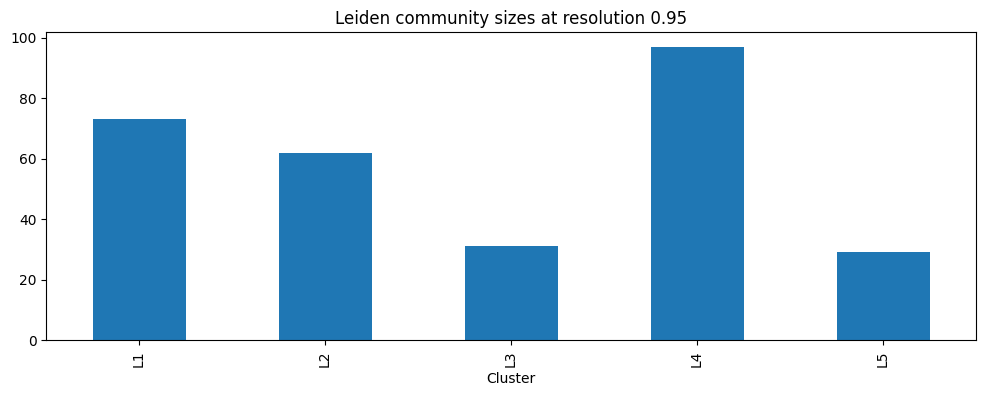

In [282]:
LEIDEN_INSPECT_RESOLUTION = globals().get('SELECTED_LEIDEN_RESOLUTION', 0.95)
# Accept results already computed with an unrounded np.arange grid.
_resolution_matches = [r for r in leiden_results
                       if np.isclose(float(r), LEIDEN_INSPECT_RESOLUTION, rtol=0, atol=1e-12)]
if len(_resolution_matches) != 1:
    raise ValueError(f'Resolution {LEIDEN_INSPECT_RESOLUTION:g} is missing or ambiguous. '
                     f'Available fitted resolutions: {sorted(leiden_results)}. Rerun the sweep if needed.')
LEIDEN_INSPECT_RESOLUTION = _resolution_matches[0]
leiden_selected = leiden_results[LEIDEN_INSPECT_RESOLUTION]
leiden_labels = leiden_selected['labels']  # Same row order as embeddings and papers.
leiden_summary, leiden_papers = leiden_tables(leiden_graph, leiden_selected, papers, representatives=3)
if not 2 <= len(leiden_summary) <= LEIDEN_MAX_CLUSTERS:
    print('This resolution is outside the target range. Inspect another candidate in the table above.')
with pd.option_context('display.max_colwidth', None, 'display.max_rows', None):
    display(leiden_summary.style.format(
        {'Within-cluster similarity': '{:.3f}'}, na_rep='—', escape='html',
    ).set_properties(subset=['Representative papers'], **{'white-space': 'pre-wrap'}))
ax = leiden_summary.plot.bar(x='Cluster', y='Papers', legend=False, figsize=(12, 4))
ax.set_title(f'Leiden community sizes at resolution {LEIDEN_INSPECT_RESOLUTION}')
plt.show()


In [283]:
LEIDEN_CLUSTER_TO_INSPECT = 'L1'
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(leiden_papers.loc[leiden_papers['Cluster'] == LEIDEN_CLUSTER_TO_INSPECT])


,Cluster,Paper ID,Key,Title,source_filename,segments
0,L1,P001,b87701a573df443374b263f59e2706fb6b0fb7c9286c6c832b3d8d59d33f0ae1,ESG Disclosures in the Private Equity Industry,Abraham et al. - 2024 - ESG Disclosures in the Private Equity Industry.pdf,10
1,L1,P003,d52328858a91e1b966a1afcbec8e586e9326a702a95519d187d78319623f32f1,Corporate Governance and Value Creation: Evidence from Private Equity,Acharya et al. - 2013 - Corporate Governance and Value Creation Evidence from Private Equity.pdf,9
2,L1,P008,81ad0757eff545e59d05d95f0ae47d2fdd56a2e08906e66dc679adc45e9f779a,"Ashwini Agrawal, Prasanna Tambe",Agrawal und Tambe - 2016 - Private Equity and Workers' Career Paths The Role of Technological Change.pdf,9
3,L1,P010,230d44d09f96d2c7769aadfff1930080d1e7c2b4b45cd8121f45369de5c20dc8,Private equity in the global economy: Evidence on industry spillovers☆,Aldatmaz und Brown - 2020 - Private equity in the global economy Evidence on industry spillovers.pdf,6
4,L1,P011,427f865cd132c124d3730252ca2228fa4203b77b5ca780bef5d852112be60f94,"Leveraged buyouts, private equity and jobs","Amess und Wright - 2012 - Leveraged buyouts, private equity and jobs.pdf",5
5,L1,P015,53b77e7a3a1abe63e204f324479cde9a137671835c3d52fb188e9bcb785c1401,Private equity and human capital risk-,Antoni et al. - 2019 - Private equity and human capital risk.pdf,6
6,L1,P023,e462bbd9b1aa13b624ef4633630f3c4fd330c57e86ce33fa00471d685c3318ac,SYMPOSIU M,"Bacon et al. - 2013 - Private Equity, HRM, and Employment.pdf",2
7,L1,P024,1b2fc7f766f98eb98d5d3ac13a7b16f31eab1fd09300c29cd6a74dfa19dc7993,The separation of ownership and control and corporate tax avoidance,Badertscher et al. - 2013 - The separation of ownership and control and corporate tax avoidance.pdf,6
8,L1,P026,9bd4201216c6d2c29943a70b3e5f060dcb78b23f57424c1dd3aac918fcfdacc7,Journal of Accounting and Economics,Baik - 2026 - Earnings management in private equity portfolio firms during fundraising.pdf,8
9,L1,P027,02ed438ed5be01ae8366e49da25ef86753a4899afd467d09182d29ccdf3b34cc,Do Public Financial Statements Influence Private Equity and Venture Capital Financing?,Baik et al. - 2025 - Do Public Financial Statements Influence Private Equity and Venture Capital Financing.pdf,9


Before choosing a partition, inspect the themes and outliers and repeat with a few neighbour counts (for example 10, 15 and 25). Stable random-seed results do not establish robustness to graph construction or embedding choices. Leiden does not guarantee balanced sizes or eliminate singletons. All results remain in memory; these cells do not recompute embeddings or export assignments.


### Five-cluster resolution choices: PDFs and abstracts

The graph overlays **PDFs (blue)** and **abstracts (orange)**. Solid lines use the left **cosine silhouette** axis; dashed lines use the right **seed stability ARI** axis. Numbers beside the solid points are cluster counts. Rings mark the selected five-cluster settings: **PDFs at 0.95** and **abstracts at 0.45**.

Displayed resolutions start at **0.15** and increase by **0.10**. Each series uses existing tested resolutions and ends at the last available matching point: PDFs at 1.15 and abstracts at 0.95. The complete 0.05-step sweeps are retained, with no interpolated points. The abstract diagnostic snapshot is exported by the Leiden sweep in `Clustering Abstracts.ipynb`.

In the complete PDF sweep, 0.95 has the strongest seed stability among the tested five-cluster settings: 0.90 has the same silhouette but lower stability; 1.00 has slightly higher silhouette but substantially lower stability. Coarser PDF partitions have higher silhouettes, so this supports a trade-off between thematic detail, separation and reproducibility rather than a unique optimum of five clusters. The selected abstract setting is shown as its own five-group comparison, not chosen by agreement with the PDFs.

Silhouette is computed in each corpus's original embedding space for the highest-objective seed at each resolution. Stability is the mean pairwise adjusted Rand index across seeds 42, 43 and 44 on the same graph. The PDF and abstract corpora use different embedding models and inputs, so their silhouette levels are descriptive within-corpus diagnostics, not a ranking of model quality. The two metrics also use different labelled axes; line heights must not be compared across axes.

This figure highlights the requested abstract five-cluster setting without changing the separate six-cluster abstract topic-analysis export. PNG, PDF, SVG and the plotted diagnostic rows are saved together.


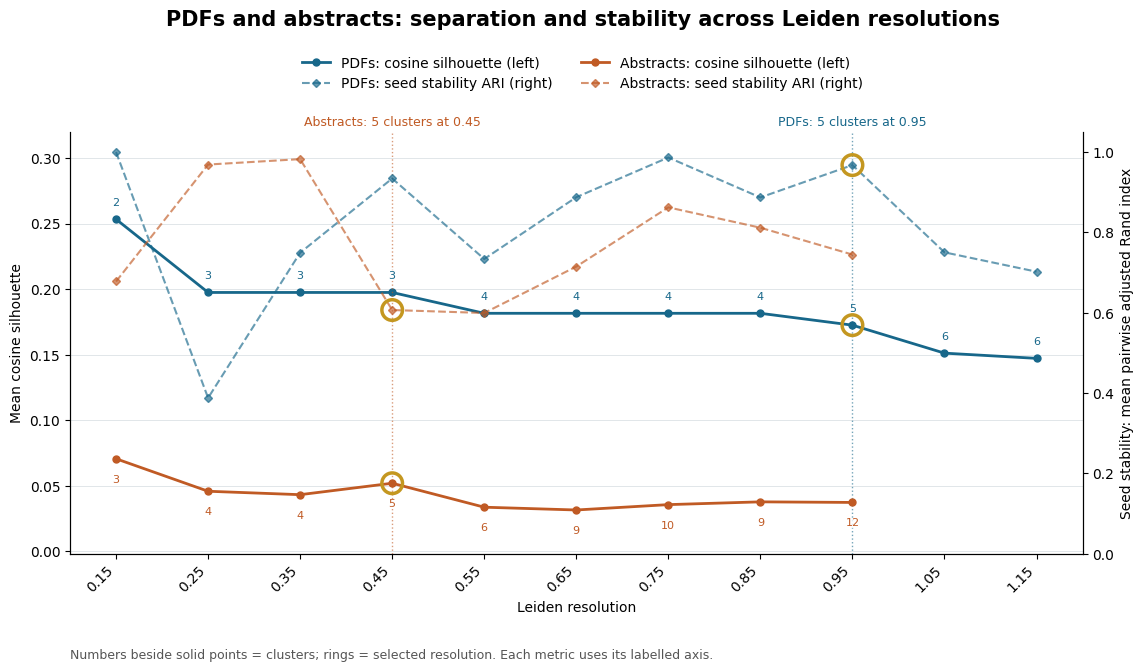

Saved combined resolution-selection figure and data: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/pdf_clustering/d4437a4c2460707a


In [284]:
# Refresh helper code in an already-running kernel; fitted results stay in memory.
import importlib
import json
import batill.graph_clustering as graph_clustering
importlib.reload(graph_clustering)
from batill.graph_clustering import plot_leiden_resolution_selection
from batill.storage import file_hash

# This snapshot is exported by the sweep cell in Clustering Abstracts.ipynb.
ABSTRACT_DIAGNOSTICS_DIR = ROOT / 'reports/abstract_clustering/fab1ccb1023ccc11'
abstract_diagnostics_csv = ABSTRACT_DIAGNOSTICS_DIR / 'leiden_resolution_diagnostics.csv'
abstract_sweep_manifest = ABSTRACT_DIAGNOSTICS_DIR / 'sweep_manifest.json'
if not abstract_diagnostics_csv.exists() or not abstract_sweep_manifest.exists():
    raise FileNotFoundError('Run setup/loading and the Leiden sweep in Clustering Abstracts.ipynb first.')
abstract_sweep_provenance = json.loads(abstract_sweep_manifest.read_text())
if file_hash(abstract_diagnostics_csv) != abstract_sweep_provenance['diagnostics_sha256']:
    raise ValueError('Abstract sweep checksum changed; rerun its source sweep export.')
abstract_leiden_diagnostics = pd.read_csv(abstract_diagnostics_csv)

# Thin the displayed series only; retain the complete diagnostic sweeps.
# Each corpus ends at its last available tested resolution on this display grid.
DISPLAY_RESOLUTIONS = np.round(np.arange(0.15, 1.25, 0.1), 2)
full_resolution_sweeps = {'PDFs': leiden_diagnostics.copy(),
                          'Abstracts': abstract_leiden_diagnostics}
resolution_sweeps = {
    name: table.loc[np.isclose(table.resolution.to_numpy()[:, None],
                               DISPLAY_RESOLUTIONS[None, :], rtol=0, atol=1e-12).any(axis=1)].copy()
    for name, table in full_resolution_sweeps.items()
}
resolution_choices = {'PDFs': 0.95, 'Abstracts': 0.45}
for name, table in resolution_sweeps.items():
    chosen = table.loc[np.isclose(table.resolution, resolution_choices[name], rtol=0, atol=1e-12)]
    if len(chosen) != 1 or int(chosen.iloc[0]['clusters']) != 5:
        raise ValueError(f'{name}: the selected resolution must be present and yield five clusters.')

resolution_selection_figure, resolution_selection_axes = plot_leiden_resolution_selection(
    resolution_sweeps, resolution_choices, show_selected_values=False,
    title='PDFs and abstracts: separation and stability across Leiden resolutions',
)
RESOLUTION_FIGURES = (ROOT / 'reports' / 'pdf_clustering'
                      / analysis_selection['selection_id'][:16])
RESOLUTION_FIGURES.mkdir(parents=True, exist_ok=True)
for extension in ('png', 'pdf', 'svg'):
    resolution_selection_figure.savefig(
        RESOLUTION_FIGURES / f'leiden_resolution_selection.{extension}',
        dpi=200, bbox_inches='tight')
# Preserve the full PDF sweep and export exactly the data displayed in both curves.
leiden_diagnostics.to_csv(RESOLUTION_FIGURES / 'leiden_resolution_diagnostics.csv', index=False)
pd.concat([table.assign(corpus=name) for name, table in resolution_sweeps.items()],
          ignore_index=True).to_csv(RESOLUTION_FIGURES / 'combined_resolution_diagnostics.csv', index=False)
plt.show()
print('Saved combined resolution-selection figure and data:', RESOLUTION_FIGURES)


## 2a. PCA

PCA is a deterministic linear projection. Its explained-variance percentages show how much of the original variation these two axes retain. A low percentage means that substantial structure is omitted from this view.


In [285]:
pca = PCA(n_components=2, svd_solver="full")
pca_coordinates = pca.fit_transform(embeddings)
papers["PCA 1"] = pca_coordinates[:, 0]
papers["PCA 2"] = pca_coordinates[:, 1]
assert np.isfinite(pca_coordinates).all()
print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance shown: {pca.explained_variance_ratio_.sum():.1%}")


PC1 explained variance: 13.3%
PC2 explained variance: 8.0%
Total variance shown: 21.3%


In [286]:
try:
    import plotly.express as px
except ImportError as exc:
    raise ImportError("Install Plotly in this kernel with %pip install plotly, then rerun this cell.") from exc

def hover_text(value, width=70):
    return "<br>".join(html.escape(line) for line in textwrap.wrap(str(value), width=width))

plot_data = papers.copy()
plot_data["Paper"] = plot_data["Title"].map(hover_text)
plot_data["Text preview"] = plot_data["text_preview"].map(
    lambda text: hover_text(text[:350] + ("…" if len(text) > 350 else ""))
)

def embedding_plot(frame, x, y, title):
    fig = px.scatter(
        frame, x=x, y=y,
        color="input_status", symbol="input_status",
        color_discrete_map={"Single input": "#3573A5", "Multiple segments": "#D66A24"},
        symbol_map={"Single input": "circle", "Multiple segments": "diamond"},
        hover_name="Paper",
        hover_data={"Key": True, "source_filename": True, "segments": True,
                    "Text preview": True, "embedding_tokens": True,
                    "input_status": False, x: False, y: False},
        labels={"input_status": "Embedding input", "embedding_tokens": "Input tokens"},
        title=title, template="plotly_white", height=650,
    )
    fig.update_traces(marker={"size": 8, "opacity": 0.8})
    fig.update_layout(legend={"orientation": "h", "y": 1.06, "x": 0})
    return fig

pca_figure = embedding_plot(plot_data, "PCA 1", "PCA 2", "Papers in PCA space")
pca_figure.update_xaxes(title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
pca_figure.update_yaxes(title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
pca_figure.show()


## 2b. UMAP

UMAP emphasizes neighbourhood structure and can reveal nonlinear patterns. This view uses cosine distance on the original embeddings, with a fixed seed for reproducibility. The axes have no direct semantic meaning, and apparent islands are not proof of distinct research topics.

`n_neighbors` controls the balance between local and broader structure; `min_dist` controls how tightly points can pack in the plot. Colours flag multi-segment inputs, **not clusters**. Compare the same papers in both projections.


In [287]:
try:
    import umap
except ImportError as exc:
    raise ImportError("Install UMAP in this kernel with %pip install umap-learn, then rerun this cell.") from exc

UMAP_NEIGHBOURS = min(15, len(papers) - 1)
UMAP_MIN_DIST = 0.1
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBOURS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
umap_coordinates = reducer.fit_transform(embeddings)
assert umap_coordinates.shape == (len(papers), 2) and np.isfinite(umap_coordinates).all()
papers["UMAP 1"] = plot_data["UMAP 1"] = umap_coordinates[:, 0]
papers["UMAP 2"] = plot_data["UMAP 2"] = umap_coordinates[:, 1]
umap_figure = embedding_plot(plot_data, "UMAP 1", "UMAP 2", "Papers in UMAP space")
umap_figure.show()


## Compare neighbourhood preservation

Trustworthiness (0–1; higher is better) measures whether neighbours in the 2D projection were neighbours in the original space. We use cosine distance in that original space and up to 15 neighbours for both projections (fewer for small corpora). This is a projection diagnostic, not a measure of thematic correctness or clustering quality.


In [288]:
CHECK_NEIGHBOURS = min(15, (len(papers) - 1) // 2)
if CHECK_NEIGHBOURS < 1:
    raise ValueError('Trustworthiness requires at least three papers.')
projection_checks = pd.DataFrame({
    'Projection': ['PCA', 'UMAP'],
    f'Trustworthiness ({CHECK_NEIGHBOURS} neighbours)': [
        trustworthiness(embeddings, pca_coordinates, n_neighbors=CHECK_NEIGHBOURS, metric='cosine'),
        trustworthiness(embeddings, umap_coordinates, n_neighbors=CHECK_NEIGHBOURS, metric='cosine'),
    ],
})
display(projection_checks)

,Projection,Trustworthiness (15 neighbours)
0,PCA,0.811579
1,UMAP,0.894787


Record observations below before choosing a clustering method: do neighbours share a research question or merely vocabulary? Are any papers unexpectedly close? Do multi-segment papers have plausible neighbours? Avoid assigning topics from the 2D layout alone.

**Review notes:**

- Paper keys examined:
- Neighbours that make sense and why:
- Questionable matches:
- Differences between PCA and UMAP:

No new data files are created by this notebook. `papers` holds the aligned metadata and projection coordinates for the clustering comparison below.


### PCA and UMAP coloured by the chosen Leiden resolution

Choose any resolution already computed in the sweep. These plots reuse the earlier PCA and UMAP coordinates; **Leiden is still fitted to the original embedding similarity graph**. Both plots use the same community colours. Changing this resolution only changes the displayed labels; it does not refit projections or overwrite the resolution used by the previous representative table. Both controls default to SELECTED_LEIDEN_RESOLUTION from the graph setup cell.


In [289]:
LEIDEN_PLOT_RESOLUTION = globals().get('SELECTED_LEIDEN_RESOLUTION', 0.95)
# Accept results already computed with an unrounded np.arange grid.
_resolution_matches = [r for r in leiden_results
                       if np.isclose(float(r), LEIDEN_PLOT_RESOLUTION, rtol=0, atol=1e-12)]
if len(_resolution_matches) != 1:
    raise ValueError(f'Resolution {LEIDEN_PLOT_RESOLUTION:g} is missing or ambiguous. '
                     f'Available fitted resolutions: {sorted(leiden_results)}. Rerun the sweep if needed.')
LEIDEN_PLOT_RESOLUTION = _resolution_matches[0]
required_columns = ['PCA 1', 'PCA 2', 'UMAP 1', 'UMAP 2']
if any(column not in plot_data for column in required_columns):
    raise RuntimeError('Run the earlier PCA and UMAP cells before this view.')

leiden_projection = plot_data.copy()
plot_labels = leiden_results[LEIDEN_PLOT_RESOLUTION]['labels']
assert len(plot_labels) == len(leiden_projection)
leiden_projection['Leiden community'] = [f'L{i}' for i in plot_labels]
community_order = [f'L{i}' for i in sorted(np.unique(plot_labels))]
community_colors = {
    label: px.colors.qualitative.Alphabet[i % len(px.colors.qualitative.Alphabet)]
    for i, label in enumerate(community_order)
}
leiden_projection_figures = []
for x, y, projection in [('PCA 1', 'PCA 2', 'PCA'), ('UMAP 1', 'UMAP 2', 'UMAP')]:
    figure = px.scatter(
        leiden_projection, x=x, y=y, color='Leiden community',
        category_orders={'Leiden community': community_order}, color_discrete_map=community_colors,
        hover_name='Paper', hover_data={'Paper ID': True, 'Key': True, 'source_filename': True,
            'segments': True, 'Text preview': True, x: False, y: False},
        title=f'Leiden resolution {LEIDEN_PLOT_RESOLUTION}: {len(community_order)} communities in {projection}',
        template='plotly_white', height=650,
    )
    figure.update_traces(marker={'size': 8, 'opacity': .8})
    if projection == 'PCA':
        figure.update_xaxes(title=f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
        figure.update_yaxes(title=f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    figure.show()
    leiden_projection_figures.append(figure)


## 3. Compare cluster counts: K-means, k = 2–15

Fit K-means to the original normalized full-dimensional embeddings, not the PCA/UMAP coordinates. Standard K-means optimizes squared Euclidean distance to its centroids; cosine silhouette provides a complementary check of angular separation between papers.

For each k, run five seeds with ten initializations per seed. Retain the fit with the lowest inertia, independently of its silhouette score. Also cluster five random 80% subsamples. Compare seed runs using Adjusted Rand Index (ARI), and subsample runs using ARI on their shared papers. ARI = 1 means identical groupings, approximately 0 means chance-level agreement; negative values are possible. Stability alone does not establish meaningful topics.

This is an exploratory search range, not a claim that the true number of themes lies within it. If promising results occur at k = 15, consider extending the range.


In [290]:
from itertools import combinations
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
from threadpoolctl import threadpool_limits

K_VALUES = list(range(2, min(15, int(len(embeddings) * 0.8) - 1) + 1))
if not K_VALUES:
    raise ValueError("Too few papers for this cluster-count sweep.")
KMEANS_SEEDS = [11, 22, 33, 44, 55]
N_INIT = 10
SUBSAMPLE_FRACTION = 0.8
SUBSAMPLE_SEEDS = [101, 202, 303, 404, 505]

assert max(K_VALUES) < int(len(embeddings) * SUBSAMPLE_FRACTION)
distance_matrix = cosine_distances(embeddings)
distance_matrix = np.maximum((distance_matrix + distance_matrix.T) / 2, 0)
np.fill_diagonal(distance_matrix, 0)

subsample_indices = [
    np.sort(np.random.default_rng(seed).choice(
        len(embeddings), size=int(len(embeddings) * SUBSAMPLE_FRACTION), replace=False
    )) for seed in SUBSAMPLE_SEEDS
]
kmeans_fit_input_id = pdf_partition_input_id(papers.Key, embeddings)
kmeans_results = {}
sweep_rows = []

# Limit BLAS threads to avoid overhead for this relatively small corpus.
with threadpool_limits(limits=1):
    for k in K_VALUES:
        runs = []
        for seed in KMEANS_SEEDS:
            model_k = KMeans(n_clusters=k, n_init=N_INIT, random_state=seed)
            labels = model_k.fit_predict(embeddings)
            scores = silhouette_samples(distance_matrix, labels, metric="precomputed")
            runs.append({"model": model_k, "labels": labels, "silhouettes": scores, "seed": seed})
        best = min(runs, key=lambda run: run["model"].inertia_)
        seed_aris = [adjusted_rand_score(a["labels"], b["labels"]) for a, b in combinations(runs, 2)]

        subsample_labels = []
        for seed, indices in zip(SUBSAMPLE_SEEDS, subsample_indices):
            labels = KMeans(n_clusters=k, n_init=N_INIT, random_state=seed).fit_predict(embeddings[indices])
            subsample_labels.append(labels)
        subsample_aris = []
        for a, b in combinations(range(len(subsample_indices)), 2):
            common, ia, ib = np.intersect1d(subsample_indices[a], subsample_indices[b], return_indices=True)
            subsample_aris.append(adjusted_rand_score(subsample_labels[a][ia], subsample_labels[b][ib]))

        sizes = np.bincount(best["labels"], minlength=k)
        run_silhouettes = [run["silhouettes"].mean() for run in runs]
        sweep_rows.append({
            "k": k, "inertia": best["model"].inertia_,
            "silhouette_best_fit": best["silhouettes"].mean(),
            "silhouette_mean": np.mean(run_silhouettes), "silhouette_std": np.std(run_silhouettes),
            "seed_ARI_mean": np.mean(seed_aris), "seed_ARI_std": np.std(seed_aris),
            "subsample_ARI_mean": np.mean(subsample_aris), "subsample_ARI_std": np.std(subsample_aris),
            "smallest_cluster": sizes.min(), "largest_cluster": sizes.max(),
            "negative_silhouette_fraction": np.mean(best["silhouettes"] < 0),
        })
        kmeans_results[k] = {**best, "runs": runs, "subsample_aris": subsample_aris, "seed_aris": seed_aris}
        print(f"k={k:2d}: silhouette={best['silhouettes'].mean():.3f}, "
              f"seed ARI={np.mean(seed_aris):.3f}, subsample ARI={np.mean(subsample_aris):.3f}")

kmeans_summary = pd.DataFrame(sweep_rows)
display(kmeans_summary.round(3))

# Save full-precision diagnostics for the combined K-means comparison.
from batill.storage import file_hash, write_json
KMEANS_DIAGNOSTICS_DIR = ROOT / 'reports/pdf_clustering' / analysis_selection['selection_id'][:16]
KMEANS_DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)
KMEANS_DIAGNOSTICS_CSV = KMEANS_DIAGNOSTICS_DIR / 'kmeans_diagnostics.csv'
kmeans_summary.to_csv(KMEANS_DIAGNOSTICS_CSV, index=False)
write_json(KMEANS_DIAGNOSTICS_DIR / 'kmeans_sweep_manifest.json', {
    'source_notebook': 'Clustering PDFs.ipynb', 'input_id': kmeans_fit_input_id,
    'papers': len(papers), 'k_values': K_VALUES, 'seeds': KMEANS_SEEDS, 'n_init': N_INIT,
    'best_fit_rule': 'minimum inertia across seeds',
    'mean_rule': 'mean of each seed fit silhouette',
    'diagnostics_sha256': file_hash(KMEANS_DIAGNOSTICS_CSV),
})
print('Saved K-means diagnostics:', KMEANS_DIAGNOSTICS_DIR)


k= 2: silhouette=0.169, seed ARI=0.959, subsample ARI=0.851
k= 3: silhouette=0.207, seed ARI=0.944, subsample ARI=0.883
k= 4: silhouette=0.189, seed ARI=0.857, subsample ARI=0.775
k= 5: silhouette=0.178, seed ARI=0.865, subsample ARI=0.809
k= 6: silhouette=0.158, seed ARI=0.689, subsample ARI=0.732
k= 7: silhouette=0.167, seed ARI=0.641, subsample ARI=0.581
k= 8: silhouette=0.153, seed ARI=0.600, subsample ARI=0.473
k= 9: silhouette=0.116, seed ARI=0.532, subsample ARI=0.488
k=10: silhouette=0.089, seed ARI=0.485, subsample ARI=0.520
k=11: silhouette=0.115, seed ARI=0.550, subsample ARI=0.482
k=12: silhouette=0.118, seed ARI=0.532, subsample ARI=0.435
k=13: silhouette=0.109, seed ARI=0.432, subsample ARI=0.436
k=14: silhouette=0.099, seed ARI=0.471, subsample ARI=0.404
k=15: silhouette=0.105, seed ARI=0.461, subsample ARI=0.415


,k,inertia,silhouette_best_fit,silhouette_mean,silhouette_std,seed_ARI_mean,seed_ARI_std,subsample_ARI_mean,subsample_ARI_std,smallest_cluster,largest_cluster,negative_silhouette_fraction
0,2,74.249,0.169,0.169,0.001,0.959,0.020,0.851,0.065,125,167,0.171
1,3,68.736,0.207,0.208,0.002,0.944,0.062,0.883,0.077,29,140,0.123
2,4,65.709,0.189,0.192,0.002,0.857,0.083,0.775,0.094,29,109,0.140
3,5,63.528,0.178,0.182,0.003,0.865,0.043,0.809,0.053,29,101,0.092
4,6,62.260,0.158,0.153,0.009,0.689,0.084,0.732,0.078,29,92,0.116
5,7,60.868,0.167,0.147,0.020,0.641,0.078,0.581,0.100,9,98,0.178
6,8,59.839,0.153,0.136,0.020,0.600,0.070,0.473,0.081,17,82,0.123
7,9,58.743,0.116,0.120,0.018,0.532,0.052,0.488,0.059,11,52,0.209
8,10,57.939,0.089,0.101,0.009,0.485,0.068,0.520,0.067,9,67,0.240
9,11,56.921,0.115,0.113,0.011,0.550,0.042,0.482,0.069,9,71,0.243


Saved K-means diagnostics: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/pdf_clustering/d4437a4c2460707a


### K-means: silhouette across cluster counts

Compare **PDFs (blue)** and **abstracts (orange)**, with **k = 5** highlighted. Solid circles show `silhouette_best_fit`: the mean cosine silhouette of the run selected by **minimum inertia** at each k. Dashed diamonds show `silhouette_mean`: the average of the five seed runs' mean cosine silhouettes. The best-inertia fit need not have the highest silhouette, so its curve can lie below the seed mean.

The left and right axes use the **same silhouette scale**. All tested integer values of k are shown. The highlighted five-group choice is a level of thematic detail for interpretation; it is not claimed to maximize silhouette. These corpora use different inputs and embedding models, so compare trends within each corpus rather than treating absolute silhouette levels as a model ranking. Seed and subsample stability are examined in the following section.

The abstract series comes from the saved full-precision K-means sweep in `Clustering Abstracts.ipynb`. This graph highlights five groups without changing the separate six-cluster abstract topic export. The figure and its plotted data are saved alongside the Leiden comparison.


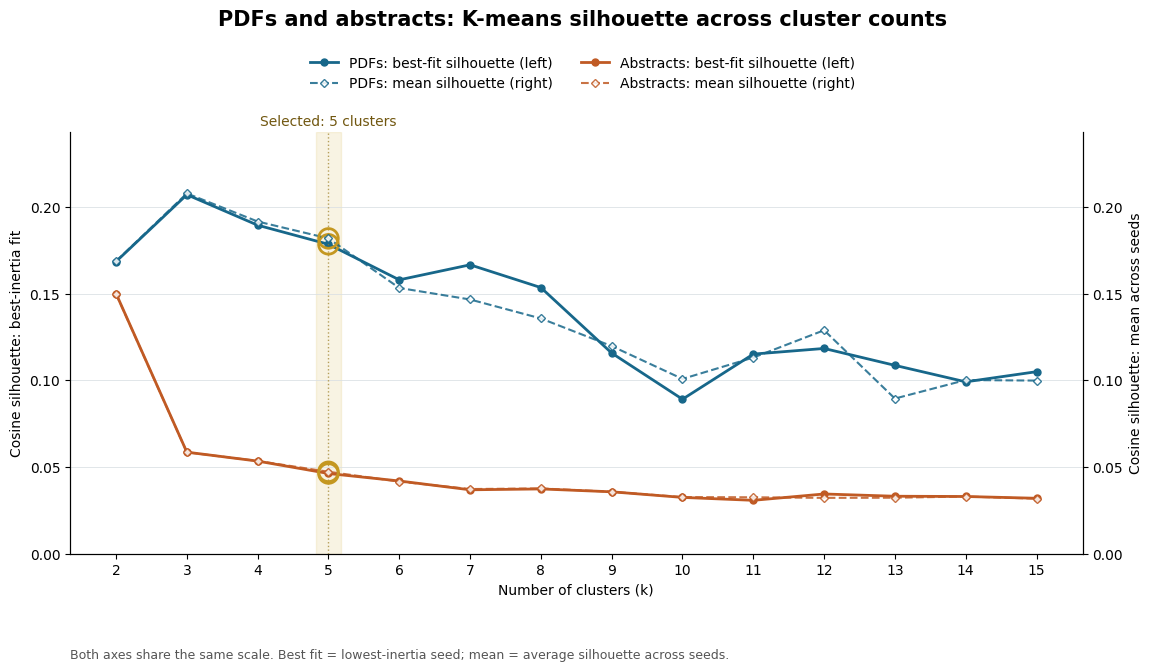

Saved K-means comparison and data: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/pdf_clustering/d4437a4c2460707a


In [291]:
# Refresh plot helpers in an already-running kernel.
import importlib
import json
import matplotlib.pyplot as plt
import batill.clustering as clustering_plots
importlib.reload(clustering_plots)
from batill.clustering import plot_kmeans_selection
from batill.storage import file_hash

ABSTRACT_KMEANS_DIR = ROOT / 'reports/abstract_clustering/fab1ccb1023ccc11'
abstract_kmeans_csv = ABSTRACT_KMEANS_DIR / 'kmeans_diagnostics.csv'
abstract_kmeans_manifest = ABSTRACT_KMEANS_DIR / 'kmeans_sweep_manifest.json'
if not abstract_kmeans_csv.exists() or not abstract_kmeans_manifest.exists():
    raise FileNotFoundError('Run setup/loading and the K-means sweep in Clustering Abstracts.ipynb first.')
abstract_kmeans_provenance = json.loads(abstract_kmeans_manifest.read_text())
if file_hash(abstract_kmeans_csv) != abstract_kmeans_provenance['diagnostics_sha256']:
    raise ValueError('Abstract K-means diagnostics changed; rerun the source sweep export.')
abstract_kmeans_summary = pd.read_csv(abstract_kmeans_csv)

kmeans_comparison_sweeps = {'PDFs': kmeans_summary.copy(), 'Abstracts': abstract_kmeans_summary}
KMEANS_FIGURE_K = 5
kmeans_selection_figure, kmeans_selection_axes = plot_kmeans_selection(
    kmeans_comparison_sweeps, selected_k=KMEANS_FIGURE_K,
)
KMEANS_FIGURES = ROOT / 'reports/pdf_clustering' / analysis_selection['selection_id'][:16]
KMEANS_FIGURES.mkdir(parents=True, exist_ok=True)
for extension in ('png', 'pdf', 'svg'):
    kmeans_selection_figure.savefig(KMEANS_FIGURES / f'kmeans_cluster_selection.{extension}',
                                   dpi=200, bbox_inches='tight')
pd.concat([table.assign(corpus=name) for name, table in kmeans_comparison_sweeps.items()],
          ignore_index=True).to_csv(KMEANS_FIGURES / 'combined_kmeans_diagnostics.csv', index=False)
plt.show()
print('Saved K-means comparison and data:', KMEANS_FIGURES)


## 4. Inspect separation, elbow and stability

Inertia always decreases as k grows; look for diminishing gains, not the minimum. Silhouette and stability may favour different resolutions. Error bars show descriptive variation across runs/pairs, not confidence intervals: the comparisons share data and are not independent. The size panel shows the smallest and largest cluster in each retained fit.


In [292]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

diagnostics_figure = make_subplots(rows=2, cols=2, subplot_titles=[
    "Cosine silhouette", "Inertia: look for diminishing gains",
    "Assignment stability (ARI)", "Cluster size range",
])
s = kmeans_summary
diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s.silhouette_mean, mode="lines+markers",
    name="Silhouette across seeds", error_y={"type": "data", "array": s.silhouette_std}), row=1, col=1)
diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s.inertia, mode="lines+markers", name="Lowest inertia"), row=1, col=2)
for prefix, label in [("seed", "Different initializations"), ("subsample", "80% subsamples")]:
    diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s[f"{prefix}_ARI_mean"], mode="lines+markers",
        name=label, error_y={"type": "data", "array": s[f"{prefix}_ARI_std"]}), row=2, col=1)
for column, label in [("smallest_cluster", "Smallest cluster"), ("largest_cluster", "Largest cluster")]:
    diagnostics_figure.add_trace(go.Scatter(x=s.k, y=s[column], mode="lines+markers", name=label), row=2, col=2)
diagnostics_figure.update_xaxes(title_text="Number of clusters (k)", dtick=1)
diagnostics_figure.update_yaxes(title_text="Cosine silhouette", row=1, col=1)
diagnostics_figure.update_yaxes(title_text="Squared Euclidean distances", row=1, col=2)
diagnostics_figure.update_yaxes(title_text="Adjusted Rand Index", row=2, col=1)
diagnostics_figure.update_yaxes(title_text="Papers", row=2, col=2)
diagnostics_figure.update_layout(template="plotly_white", height=800, title="K-means model comparison",
    legend={"orientation": "h", "y": -0.15})
diagnostics_figure.show()


## 5. Shortlist candidate resolutions

The default shortlist contains the three highest mean silhouette scores and the selected k=5 topic partition. It is only a starting point, not an automatic selection. Edit `CANDIDATE_KS` after examining the elbow and stability curves; a stable, interpretable finer partition may be useful even if its silhouette is lower.

Keywords below are terms whose average TF-IDF is higher inside the cluster than outside it. They are descriptive suggestions, not validated topic names. English stopword filtering here affects keyword summaries only; the original embeddings are unchanged.


In [293]:
CANDIDATE_KS = sorted(set(kmeans_summary.nlargest(3, "silhouette_mean")["k"].astype(int).tolist()) | {5})
# Example manual override after inspecting the diagnostics: CANDIDATE_KS = [3, 6, 9]
assert all(k in kmeans_results for k in CANDIDATE_KS)
display(kmeans_summary.loc[kmeans_summary.k.isin(CANDIDATE_KS)].round(3))

keyword_vectorizer = TfidfVectorizer(
    stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True
)
keyword_matrix = keyword_vectorizer.fit_transform(papers["embedding_text"])
terms = keyword_vectorizer.get_feature_names_out()

def cluster_overview(k, top_terms=8):
    result = kmeans_results[k]
    labels, sil = result["labels"], result["silhouettes"]
    rows = []
    for cluster in range(k):
        mask = labels == cluster
        inside = np.asarray(keyword_matrix[mask].mean(axis=0)).ravel()
        outside = np.asarray(keyword_matrix[~mask].mean(axis=0)).ravel()
        contrast = inside - outside
        top = np.argsort(-contrast)[:top_terms]
        keywords = ", ".join(terms[i] for i in top if contrast[i] > 0)
        rows.append({"cluster": cluster, "papers": int(mask.sum()),
            "mean_cosine_silhouette": sil[mask].mean(),
            "negative_silhouette_fraction": (sil[mask] < 0).mean(),
            "multi_segment_papers": int(segmented[mask].sum()), "distinctive_terms": keywords})
    return pd.DataFrame(rows)

def cluster_examples(k):
    result = kmeans_results[k]
    labels, sil = result["labels"], result["silhouettes"]
    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for cluster in range(k):
        members = np.flatnonzero(labels == cluster)
        center = result["model"].cluster_centers_[cluster]
        centrality = cosine_similarity(embeddings[members], center.reshape(1, -1)).ravel()
        central = members[np.argsort(-centrality)[:3]]
        boundary = members[np.argsort(sil[members])[:2]]
        remaining = np.setdiff1d(members, np.union1d(central, boundary))
        random_rows = rng.choice(remaining, size=min(2, len(remaining)), replace=False)
        # If a small cluster overlaps categories, preserve both reasons on one row.
        reasons = {}
        for category, indices in [("Representative", central), ("Lowest silhouette", boundary), ("Random", random_rows)]:
            for index in indices:
                reasons.setdefault(int(index), []).append(category)
        for index, categories in reasons.items():
            paper = papers.iloc[index]
            rows.append({"cluster": cluster, "selection": "; ".join(categories),
                "Key": paper["Key"], "Title": paper["Title"],
                "cosine_silhouette": sil[index], "input_status": paper["input_status"],
                "text_preview": paper["text_preview"]})
    return pd.DataFrame(rows)

SHOW_TEXT = False  # Set True when reading candidate papers in detail.
candidate_overviews = {}
candidate_examples = {}
for k in CANDIDATE_KS:
    print(f"Candidate k={k} — cluster IDs have meaning only within this fit")
    candidate_overviews[k] = cluster_overview(k)
    candidate_examples[k] = cluster_examples(k)
    with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
        display(candidate_overviews[k].round(3))
        example_table = candidate_examples[k]
        display((example_table if SHOW_TEXT else example_table.drop(columns="text_preview")).round(3))


,k,inertia,silhouette_best_fit,silhouette_mean,silhouette_std,seed_ARI_mean,seed_ARI_std,subsample_ARI_mean,subsample_ARI_std,smallest_cluster,largest_cluster,negative_silhouette_fraction
1,3,68.736,0.207,0.208,0.002,0.944,0.062,0.883,0.077,29,140,0.123
2,4,65.709,0.189,0.192,0.002,0.857,0.083,0.775,0.094,29,109,0.140
3,5,63.528,0.178,0.182,0.003,0.865,0.043,0.809,0.053,29,101,0.092


Candidate k=3 — cluster IDs have meaning only within this fit


,cluster,papers,mean_cosine_silhouette,negative_silhouette_fraction,multi_segment_papers,distinctive_terms
0,0,29,0.406,0.000,29,"physician, hospital, patients, physicians, care, health, hospitals, health care"
1,1,140,0.076,0.257,138,"lbos, lbo, announcement, post buyout, shareholders, takeover, bid, buyouts"
2,2,123,0.309,0.000,123,"lps, vc, vintage, gps, gp, irr, pme, lp"


,cluster,selection,Key,Title,cosine_silhouette,input_status
0,0,Representative,40efdc98e3f66a3361e4ff3f9e4309f74a430566d8de7164eb1e15c9621890da,"Evaluating trends in private equity ownership and impacts on health outcomes, costs, and quality: systematic review",0.540,Multiple segments
1,0,Representative,9817f0834ce1564946c1e45014119d21c7957219d97e195caae1c913fa39fa4f,"Changes in Hospital Income, Use, and Quality Associated With Private Equity Acquisition",0.511,Multiple segments
2,0,Representative,bb793909914da7350d74ccde8c739b40c7d853553ed8d0d60059cc761abb5b08,Association Between Hospital Private Equity Acquisition and Outcomes of Acute Medical Conditions Among Medicare Beneficiaries,0.528,Multiple segments
3,0,Lowest silhouette,dbfea60142749b06663396f1c875ef3d35ef6dcf8dba7fe038b50288383d6174,How Deadly Is Financial Leverage? Evidence from Care Homes During the COVID-19 Crisis,0.211,Multiple segments
4,0,Lowest silhouette,7b5e1546a2419438cc557f16aee95277c4023f0654d0e480e1231404f0a58fbe,"Private Equity Buyouts in Healthcare: Who Wins, Who Loses? Eileen Appelbaum∗ and Rosemary Batt†",0.258,Multiple segments
5,0,Random,09acb39e45f5d3d803f4842b77364ff5d3a5ddc57989e28a00842a5bee6ae240,Association of Private Equity Investment in US Nursing Homes With the Quality and Cost of Care for Long-Stay Residents,0.509,Multiple segments
6,0,Random,76af053645a2c745cfa0931782c06bbe5f93866e88645525dad057f1871fbdcf,Bargaining with Private Equity: Implications for Hospital Prices and Patient Welfare,0.300,Multiple segments
7,1,Representative,00d352cd33d88dec747b7e67b51f6b2600c936d4efc46d7dde93b3e4f36a4bf8,Private equity: A review and synthesisijmr_264 361..380,-0.000,Multiple segments
8,1,Representative,d4c84438f47f1fc5d8b15d855605f85a54ccb687b74782fcfd2135023c258e5e,A theory of LBO activity based on repeated debt-equity conflicts,0.147,Multiple segments
9,1,Representative,f7c12b54865d3ecbc54e21b66e401d1170c1b0dcb2a7e9eaaa44cfce5ed32761,Leveraged Buyouts and Private Equity,-0.111,Multiple segments


Candidate k=4 — cluster IDs have meaning only within this fit


,cluster,papers,mean_cosine_silhouette,negative_silhouette_fraction,multi_segment_papers,distinctive_terms
0,0,60,0.173,0.033,58,"announcement, lbos, lbo, bidders, bidder, takeover, bid, lb0"
1,1,109,0.295,0.000,109,"lps, gps, gp, vintage, vc, lp, pme, irr"
2,2,29,0.387,0.000,29,"physician, hospital, patients, physicians, care, health, hospitals, health care"
3,3,94,0.017,0.415,94,"employment, pe backed, productivity, backed, employees, countries, job, employment growth"


,cluster,selection,Key,Title,cosine_silhouette,input_status
0,0,Representative,4622cc4051ede1b6af07f5ecbfb4e28eea41a1aab1aed73879fd8ff5f949021d,Consequences of leveraged buyouts,0.315,Multiple segments
1,0,Representative,4e22931ea66d0d335a72fae7cc54e49d0688f335fdbf3253209862101627acbd,Guo et al. - 2011 - Do Buyouts (Still) Create Value.pdf,0.270,Multiple segments
2,0,Representative,3f74a7fd0faf2cb11a02d8a2283acf52485f325e9d2cbc696896929c5f70c22d,The structure of debt and active equity investors: The case of the buyout specialistq,0.271,Multiple segments
3,0,Lowest silhouette,9d8f8313189e45bf982dc6a17f6f1288ae7598027aa2892fa650f56421ff99f5,Fund managers under pressure: Rationale and determinants of secondary buyouts,-0.053,Multiple segments
4,0,Lowest silhouette,b2bdeff481d967dff39e3632e1f5572e4c7df7bdfa46e4cb0a0b931c2b36f6a7,On secondary buyouts-,-0.051,Multiple segments
5,0,Random,483d51dc0085e76ae07e90df790b9d009198c8bafad94e4c1bee5934a74ea684,"Axelson et al. - 2013 - Borrow Cheap, Buy High The Determinants of Leverage and Pricing in Buyouts.pdf",0.148,Multiple segments
6,0,Random,524b3ba2a30227761db97e109292410f4272f1f80308b71d9514b67e7937640d,The effects of leveraged buyouts on productivity and related aspects of firm behavior*,0.153,Multiple segments
7,1,Representative,e4a1537519f0c150351a26b9945a2d5ac2d77f2f8416ebcb8f83367c6a780acd,"Kaplan und Schoar - 2005 - Private Equity Performance - Returns, Persistence, and Capital Flows.pdf",0.419,Multiple segments
8,1,Representative,91b43a24dfc7ceb2f38f93746c7943ca2e0962e45c533a87943d7970e54a9dff,The Performance of Private Equity Funds,0.412,Multiple segments
9,1,Representative,4cf9ccd4e03e0c633517c00f503e4cc3a899150c524a2ccb2faa82473bb7b91a,Raising Funds on Performance: Are Private Equity Returns Too Good to Be True?,0.379,Multiple segments


Candidate k=5 — cluster IDs have meaning only within this fit


,cluster,papers,mean_cosine_silhouette,negative_silhouette_fraction,multi_segment_papers,distinctive_terms
0,0,56,0.164,0.018,54,"lbos, announcement, lbo, bidders, bidder, takeover, bid, lb0"
1,1,72,0.082,0.167,72,"employment, pe backed, pe, employment growth, backed, productivity, pe investors, wright"
2,2,34,0.018,0.412,34,"sox, private firms, going public, public firms, equilibrium, firm value, insiders, firms public"
3,3,29,0.359,0.000,29,"physician, hospital, patients, physicians, care, health, hospitals, health care"
4,4,101,0.258,0.000,101,"lps, gps, gp, vintage, pme, vc, lp, irr"


,cluster,selection,Key,Title,cosine_silhouette,input_status
0,0,Representative,4622cc4051ede1b6af07f5ecbfb4e28eea41a1aab1aed73879fd8ff5f949021d,Consequences of leveraged buyouts,0.298,Multiple segments
1,0,Representative,4e22931ea66d0d335a72fae7cc54e49d0688f335fdbf3253209862101627acbd,Guo et al. - 2011 - Do Buyouts (Still) Create Value.pdf,0.217,Multiple segments
2,0,Representative,78fe35dd3d04023742f5c68c11e759bab9fbe90e119cfa8d07f12983c119035f,On the Heterogeneity of Leveraged Going Private Transactions,0.272,Multiple segments
3,0,Lowest silhouette,9d8f8313189e45bf982dc6a17f6f1288ae7598027aa2892fa650f56421ff99f5,Fund managers under pressure: Rationale and determinants of secondary buyouts,-0.060,Multiple segments
4,0,Lowest silhouette,5f5e80ab613d93e9b547888e3319acc94b506c5d0c7ca12c3f7907d196262c7e,"Why do public firms go private in the UK? The impact of private equity investors, incentive realignment and undervaluation",0.004,Multiple segments
5,0,Random,17a47344a8619e537614c194328d90f553ba5a363dad58dcc489688209f46ddb,Does going private add value through operating improvements?,0.139,Multiple segments
6,0,Random,ced50b46fcb727a286e8c79c01f6dd24e0a8a1b42c98058ac8568c890c947856,Consolidating corporate control,0.196,Multiple segments
7,1,Representative,00d352cd33d88dec747b7e67b51f6b2600c936d4efc46d7dde93b3e4f36a4bf8,Private equity: A review and synthesisijmr_264 361..380,0.227,Multiple segments
8,1,Representative,d52328858a91e1b966a1afcbec8e586e9326a702a95519d187d78319623f32f1,Corporate Governance and Value Creation: Evidence from Private Equity,0.047,Multiple segments
9,1,Representative,821aaf3bb89c128210af14ad6ac6d310fcac1805e5e79d37af4bf30d1aaf5d13,Private Equity and Corporate Governance: Retrospect and Prospect,0.185,Multiple segments


## Inspect a candidate in more detail

Change `INSPECT_K` to compare another fit. The box plot shows each cluster's distribution of cosine silhouettes, including overlap and negative values. PCA and UMAP merely display the same assignments: clustering and silhouette calculations used the original embeddings. Colours identify clusters within this candidate, and diamond markers identify multi-segment inputs.


In [294]:
INSPECT_K = 5  # The selected PDF topic partition, already fitted in the sweep.
assert INSPECT_K in kmeans_results
candidate = kmeans_results[INSPECT_K]
candidate_plot = plot_data.copy()
candidate_plot["Cluster"] = candidate["labels"].astype(str)
candidate_plot["Cosine silhouette"] = candidate["silhouettes"]
cluster_order = [str(i) for i in range(INSPECT_K)]

silhouette_figure = px.box(candidate_plot, x="Cluster", y="Cosine silhouette", points="outliers",
    category_orders={"Cluster": cluster_order}, hover_name="Paper",
    title=f"Per-cluster silhouette distributions: k={INSPECT_K}", template="plotly_white")
silhouette_figure.add_hline(y=0, line_dash="dash", line_color="gray")
silhouette_figure.show()

candidate_figures = []
for x, y, projection in [("PCA 1", "PCA 2", "PCA"), ("UMAP 1", "UMAP 2", "UMAP")]:
    if x not in candidate_plot or y not in candidate_plot:
        print(f"Run the earlier {projection} cell to display its cluster view.")
        continue
    figure = px.scatter(candidate_plot, x=x, y=y, color="Cluster",
        category_orders={"Cluster": cluster_order}, color_discrete_sequence=px.colors.qualitative.Alphabet,
        hover_name="Paper", hover_data={"Key": True, "source_filename": True, "segments": True,
            "Cosine silhouette": ":.3f", "Text preview": True, x: False, y: False},
        title=f"K-means k={INSPECT_K} displayed in {projection}", template="plotly_white", height=650)
    figure.update_traces(marker={"size": 8, "opacity": 0.8})
    figure.show()
    candidate_figures.append(figure)


## Export the selected five-cluster PDF-text solutions

The selected count is **five**, interpreted separately for **K-means** and **embedding-based Leiden** in `Topic analysis PDFs.ipynb`. The cell below exports existing results from `kmeans_results[5]` and `leiden_results[TOPIC_LEIDEN_RESOLUTION]`; it does not fit or merge any clusters.

`TOPIC_LEIDEN_RESOLUTION` is an explicit choice from the earlier embedding-graph sweep. It must yield exactly five communities; an incompatible setting stops the export. Inspect `leiden_diagnostics` if graph settings or scope change. K-means retains its minimum-inertia seed from the original sweep. IDs are preserved: K-means **0–4**, embedding Leiden **L1–L5**.

The export checks fit-time fingerprints, PDF identities, vectors and exclusions. It includes all selected PDFs in their original order, after the reviewed duplicate-PDF filter. Files go to `outputs/pdf_text_clusters/<selection-id>/five_clusters/`. Rerunning replaces that snapshot with these in-memory fits. Topic names are tied to membership checksums and must be reviewed if membership changes.

The recorded choice for 292 canonical PDFs is **resolution 0.95, seed 44**. It has the highest seed agreement among the tested five-community settings (mean ARI 0.968). The previous 294-PDF setting, 0.875, now yields four communities. This is an exploratory source-notebook choice, not held-out validation.


In [295]:
from batill.pdf_topic_analysis import export_pdf_topic_partitions

SELECTED_K = 5
TOPIC_LEIDEN_RESOLUTION = globals().get('SELECTED_LEIDEN_RESOLUTION', 0.95)
if SELECTED_K not in kmeans_results:
    raise RuntimeError('Run both PDF-text clustering sweeps before exporting their selected fits.')
# Accept results already computed with an unrounded np.arange grid.
_resolution_matches = [r for r in leiden_results
                       if np.isclose(float(r), TOPIC_LEIDEN_RESOLUTION, rtol=0, atol=1e-12)]
if len(_resolution_matches) != 1:
    raise ValueError(f'Resolution {TOPIC_LEIDEN_RESOLUTION:g} is missing or ambiguous. '
                     f'Available fitted resolutions: {sorted(leiden_results)}. Rerun the sweep if needed.')
TOPIC_LEIDEN_RESOLUTION = _resolution_matches[0]
if len(np.unique(leiden_results[TOPIC_LEIDEN_RESOLUTION]['labels'])) != SELECTED_K:
    raise ValueError('The chosen embedding-Leiden resolution does not have five communities. '
                     'Inspect leiden_diagnostics and explicitly select a five-community setting.')

PDF_TOPIC_EXPORT = (ROOT / 'outputs' / 'pdf_text_clusters'
                    / analysis_selection['selection_id'][:16] / 'five_clusters')
pdf_topic_assignments, pdf_topic_manifest = export_pdf_topic_partitions(
    PDF_TOPIC_EXPORT, papers, embeddings,
    kmeans_result=kmeans_results[SELECTED_K],
    leiden_result=leiden_results[TOPIC_LEIDEN_RESOLUTION],
    embedding_graph=leiden_graph,
    fit_input_ids={'kmeans_k5': kmeans_fit_input_id,
                   'embedding_leiden_k5': leiden_fit_input_id},
    input_dir=OUTPUT_DIR, exclusion_file=EXCLUSIONS_FILE,
    source_notebook=ROOT / 'Clustering PDFs.ipynb',
    settings={'kmeans_seeds': KMEANS_SEEDS, 'kmeans_n_init': N_INIT,
              'leiden_resolutions': LEIDEN_RESOLUTIONS, 'leiden_seeds': LEIDEN_SEEDS},
)
# Preserve the earlier in-memory K-means handoff for any downstream exploration.
cluster_assignments = papers[['Key', 'Title']].copy()
cluster_assignments['cluster'] = kmeans_results[SELECTED_K]['labels']
cluster_assignments['cosine_silhouette'] = kmeans_results[SELECTED_K]['silhouettes']
print('Saved exact PDF-text assignments:', PDF_TOPIC_EXPORT)
display(pdf_topic_assignments.groupby(['solution', 'cluster']).size().rename('PDFs').to_frame())
print('Open Topic analysis PDFs.ipynb to interpret these memberships.')


Saved exact PDF-text assignments: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/pdf_text_clusters/d4437a4c2460707a/five_clusters


PDFs
solution            cluster      
embedding_leiden_k5 1          73
                    2          62
                    3          31
                    4          97
                    5          29
kmeans_k5           0          56
                    1          72
                    2          34
                    3          29
                    4         101

Open Topic analysis PDFs.ipynb to interpret these memberships.


## 7. Direct-citation Leiden clustering

This section asks whether papers form similar groups based on **who cites whom**, independently of their embeddings. It uses the reviewed graph from section 7 of `Citation_graph_OpenAlex.ipynb`.

### Method

- Each node is one unique work. The current 294 selected PDFs map to 292 works; duplicate PDFs remain mapped in `pdf_to_work.csv` but count only once here.
- For clustering, connect two works if either cites the other. All links have weight 1; reciprocal citations do not double the weight. The original directed graph is preserved. This is **direct citation clustering**, not bibliographic coupling or co-citation analysis.
- Run Leiden with the RB-configuration objective over several resolutions and random seeds. Resolution controls granularity, not an exact requested number of clusters. Select the highest-objective seed **within** each resolution; never rank these objectives across resolutions.
- Works without any internal links remain in the tables and plot as **unassigned**, not artificial one-paper topic clusters. Small disconnected components are clustered but may force additional communities; inspect the component sizes before interpreting a low cluster count.
- No embeddings or UMAP coordinates enter citation clustering. The existing UMAP is only a common display.

The eight manually supplemented reference lists remain partial. Missing edges, paper age and publication versions can affect citation communities. The API-only sensitivity check below evaluates the effect of the 65 manual links.

Implementation: `src/batill/citation_clustering.py`. [Leiden implementation and objective documentation](https://leidenalg.readthedocs.io/en/stable/reference.html). Dependencies are included in the project's `graph`, `analysis` and `citations` extras.

In [296]:
from batill.citation_clustering import (
    load_citation_corpus, citation_network, citation_leiden_sweep,
    citation_cluster_tables, partition_comparison, citation_umap_comparison,
)
from batill.storage import write_json, file_hash

CITATION_GRAPH_DIR = (ROOT / 'outputs/citation_graph_openalex'
                      / scope_selection['selection_id'][:16] / 'reviewed')
INCLUDE_MANUAL_CITATIONS = True
CITATION_RESOLUTIONS = list(np.arange(0.1,1.25,0.05))
CITATION_SEEDS = [42, 43, 44]
CITATION_MAX_COMMUNITIES = 15

citation_nodes, citation_edges, citation_pdf_mapping = load_citation_corpus(
    CITATION_GRAPH_DIR, scope_papers, scope_selection['selection_id'],
)
citation_nodes['embedding_row'] = citation_nodes.Key.map(
    pd.Series(np.arange(len(papers)), index=papers.Key)).astype(int)
citation_net = citation_network(citation_nodes, citation_edges, include_manual=INCLUDE_MANUAL_CITATIONS)
CITATION_OUTPUT = (ROOT / 'outputs/citation_clustering' / scope_selection['selection_id'][:16]
                   / ('with_manual' if INCLUDE_MANUAL_CITATIONS else 'api_only'))
CITATION_OUTPUT.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame([citation_net['diagnostics']]))
print('Component sizes:', sorted(citation_net['component_sizes'], reverse=True))
print('Duplicate PDF pairs count once; canonical Paper IDs are retained.')
display(citation_pdf_mapping.loc[citation_pdf_mapping['Key'].ne(citation_pdf_mapping.canonical_key),
                                ['paper_id', 'canonical_paper_id']])
# Capture the exact graph/text/scope inputs before community detection.
from batill.citation_topic_analysis import citation_topic_input_id
citation_fit_input_id = citation_topic_input_id(
    OUTPUT_DIR, EXCLUSIONS_FILE, CITATION_GRAPH_DIR, INCLUDE_MANUAL_CITATIONS)


,works,directed_citations,undirected_links,clustered_works,isolated_works,components,nonisolated_components,largest_component_works
0,292,2539,2480,289,3,5,2,286


Component sizes: [np.int64(286), np.int64(3), np.int64(1), np.int64(1), np.int64(1)]
Duplicate PDF pairs count once; canonical Paper IDs are retained.


,paper_id,canonical_paper_id
147,P155,P154
284,P308,P020


### Resolution and seed stability

The table shows all resolutions, including those outside the 2–15-community range. `largest_component_communities` separates subdivisions of the main connected component from communities forced by disconnected components. Isolates are excluded from community counts and stability calculations.

Seed ARI measures agreement between repeated fits on the **same graph**; it does not establish robustness to missing citations. Fixed gamma-1 modularity is a descriptive graph statistic. The within-community link fraction usually rises for coarse partitions, so neither statistic should be used alone to pick the final resolution. No cosine silhouette is used to optimize citation clustering: that would favour the embedding structure we are trying to compare independently.

,resolution,communities,within_target,largest_component_communities,smallest,largest,singletons,unassigned_isolates,within_community_link_fraction,modularity_gamma_1,seed_stability_ARI_mean,seed_stability_ARI_min,selected_seed
0,0.10,2,True,1,3,286,0,3,1.000,0.002,1.000,1.000,42
1,0.15,2,True,1,3,286,0,3,1.000,0.002,1.000,1.000,42
2,0.20,2,True,1,3,286,0,3,1.000,0.002,1.000,1.000,42
3,0.25,2,True,1,3,286,0,3,1.000,0.002,1.000,1.000,42
4,0.30,2,True,1,3,286,0,3,1.000,0.002,1.000,1.000,42
5,0.35,3,True,2,3,163,0,3,0.841,0.341,0.964,0.946,42
6,0.40,3,True,2,3,163,0,3,0.841,0.341,0.982,0.973,42
7,0.45,3,True,2,3,163,0,3,0.841,0.341,1.000,1.000,42
8,0.50,4,True,3,3,142,0,3,0.826,0.359,1.000,1.000,42
9,0.55,4,True,3,3,141,0,3,0.823,0.361,0.901,0.851,42


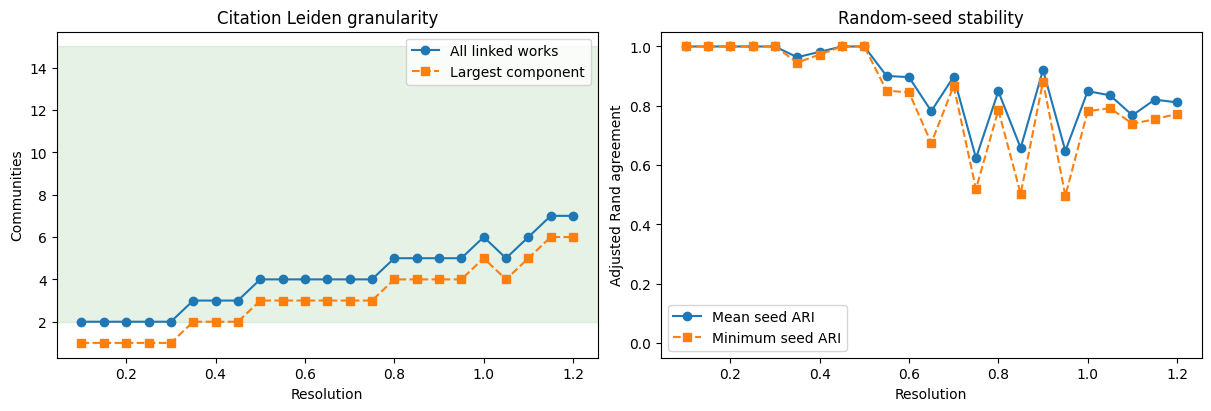

In [297]:
citation_diagnostics, citation_results = citation_leiden_sweep(
    citation_net, CITATION_RESOLUTIONS, seeds=CITATION_SEEDS,
    max_clusters=CITATION_MAX_COMMUNITIES,
)
display(citation_diagnostics.round(3))
citation_diagnostics.to_csv(CITATION_OUTPUT / 'resolution_sweep.csv', index=False)
citation_seed_rows = []
for resolution, result in citation_results.items():
    for run in result['runs']:
        for key, paper_id, label in zip(citation_nodes.Key, citation_nodes.paper_id, run['labels']):
            citation_seed_rows.append({'resolution': resolution, 'seed': run['seed'], 'Key': key,
                                       'paper_id': paper_id, 'citation_label': int(label)})
pd.DataFrame(citation_seed_rows).to_csv(CITATION_OUTPUT / 'all_seed_memberships.csv', index=False)

import matplotlib.pyplot as plt
citation_sweep_figure, citation_sweep_axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
citation_sweep_axes[0].plot(citation_diagnostics.resolution, citation_diagnostics.communities, 'o-', label='All linked works')
citation_sweep_axes[0].plot(citation_diagnostics.resolution, citation_diagnostics.largest_component_communities, 's--', label='Largest component')
citation_sweep_axes[0].axhspan(2, CITATION_MAX_COMMUNITIES, color='green', alpha=.10)
citation_sweep_axes[0].set(xlabel='Resolution', ylabel='Communities', title='Citation Leiden granularity')
citation_sweep_axes[0].legend()
citation_sweep_axes[1].plot(citation_diagnostics.resolution, citation_diagnostics.seed_stability_ARI_mean, 'o-', label='Mean seed ARI')
citation_sweep_axes[1].plot(citation_diagnostics.resolution, citation_diagnostics.seed_stability_ARI_min, 's--', label='Minimum seed ARI')
citation_sweep_axes[1].set(xlabel='Resolution', ylabel='Adjusted Rand agreement', title='Random-seed stability', ylim=(-.05, 1.05))
citation_sweep_axes[1].legend()
citation_sweep_figure.savefig(CITATION_OUTPUT / 'resolution_diagnostics.png', dpi=160)
plt.show()

### Citation modularity and seed stability across resolutions

The solid line uses **modularity at gamma = 1** on the left axis; the dashed line uses **mean seed stability ARI** on the right. Modularity is evaluated at the same gamma for every partition. Numbers beside the solid points give the number of clusters among linked works; isolates remain unassigned. Seed stability measures agreement across random seeds on the same citation graph.

The figure displays tested resolutions in **0.1 steps starting at 0.1**, with **0.9 highlighted**. The full sweep is retained. PNG, PDF, SVG and the plotted diagnostic rows are saved alongside the citation sweep.


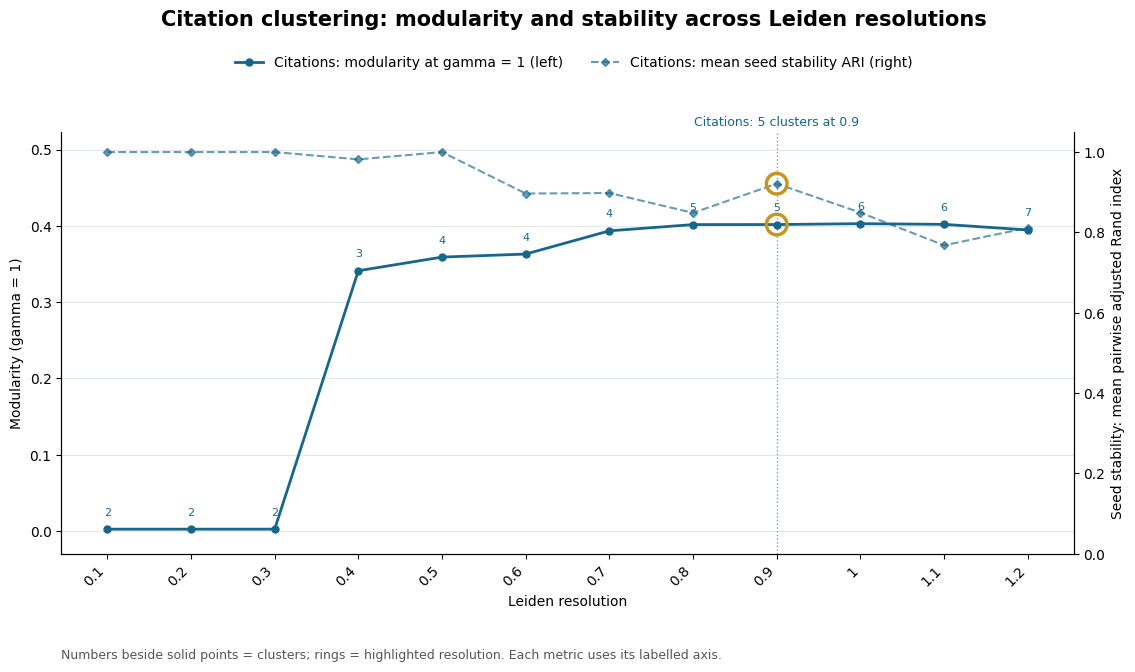

Saved citation resolution-selection figure and data: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/citation_clustering/9ad47e071ee12c2f/with_manual


In [298]:
# Refresh the plotting helper for kernels that already imported this module.
import importlib
import matplotlib.pyplot as plt
import batill.citation_clustering as citation_clustering_code
importlib.reload(citation_clustering_code)
from batill.citation_clustering import plot_citation_resolution_selection

CITATION_PLOT_RESOLUTION = 0.9
CITATION_DISPLAY_RESOLUTIONS = np.round(
    np.arange(0.1, citation_diagnostics.resolution.max() + 1e-12, 0.1), 2)
# Select actual sweep rows; tolerate arange's floating-point representation.
citation_plot_diagnostics = citation_diagnostics.loc[
    np.isclose(citation_diagnostics.resolution.to_numpy()[:, None],
               CITATION_DISPLAY_RESOLUTIONS[None, :], rtol=0, atol=1e-12).any(axis=1)
].sort_values('resolution').copy()
if (len(citation_plot_diagnostics) != len(CITATION_DISPLAY_RESOLUTIONS)
        or not np.isclose(citation_plot_diagnostics.resolution,
                          CITATION_PLOT_RESOLUTION, rtol=0, atol=1e-12).any()):
    raise ValueError('Rerun the citation setup and sweep to include the 0.1-step grid and resolution 0.9.')

citation_resolution_figure, citation_resolution_axes = plot_citation_resolution_selection(
    citation_plot_diagnostics, selected_resolution=CITATION_PLOT_RESOLUTION)
for extension in ('png', 'pdf', 'svg'):
    citation_resolution_figure.savefig(
        CITATION_OUTPUT / f'citation_resolution_selection.{extension}',
        dpi=200, bbox_inches='tight')
citation_plot_diagnostics.to_csv(
    CITATION_OUTPUT / 'citation_resolution_selection.csv', index=False)
plt.show()
print('Saved citation resolution-selection figure and data:', CITATION_OUTPUT)


### Select a resolution and inspect its communities

Change `CITATION_RESOLUTION` after reviewing the sweep. **1.0 is an initial inspection setting**, not an automatically selected optimum. The three representatives per community have the most links within that community, with incoming citations as a tie-breaker. These are citation-central examples, not automatically generated topic names.

Full membership includes isolated works and reference-coverage notes. Labels C1, C2, … belong to this citation partition only; they have no relationship to the hierarchical C-labels earlier in the notebook.

In [299]:
CITATION_RESOLUTION = 1.0
_citation_resolution_matches = [r for r in citation_results
                                if np.isclose(float(r), CITATION_RESOLUTION, rtol=0, atol=1e-12)]
if len(_citation_resolution_matches) != 1:
    raise ValueError('Choose a resolution present in CITATION_RESOLUTIONS.')
citation_selected = citation_results[_citation_resolution_matches[0]]
citation_labels = citation_selected['labels']
citation_summary, citation_membership = citation_cluster_tables(
    citation_nodes, citation_net, citation_selected, representatives=3,
)
CITATION_SELECTED_DIR = CITATION_OUTPUT / f'resolution_{CITATION_RESOLUTION:g}'
CITATION_SELECTED_DIR.mkdir(parents=True, exist_ok=True)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(citation_summary.style.set_properties(subset=['Representative papers'], **{'white-space': 'pre-wrap'}))
display(citation_membership.loc[citation_membership.citation_label.eq(0), ['paper_id', 'query_title', 'reference_coverage_note']])
citation_summary.to_csv(CITATION_SELECTED_DIR / 'community_summary.csv', index=False)
citation_membership.to_csv(CITATION_SELECTED_DIR / 'work_membership.csv', index=False)
citation_pdf_labels = citation_pdf_mapping.copy()
citation_pdf_labels['citation_label'] = citation_pdf_labels.canonical_key.map(
    pd.Series(citation_labels, index=citation_nodes.Key))
citation_pdf_labels.to_csv(CITATION_SELECTED_DIR / 'pdf_membership.csv', index=False)

CITATION_COMMUNITY_TO_INSPECT = 'C1'
display(citation_membership.loc[citation_membership['Citation community'].eq(CITATION_COMMUNITY_TO_INSPECT),
    ['paper_id', 'query_title', 'within_community_degree', 'citation_degree', 'component_size', 'reference_coverage_note']])
# Export this selected citation fit for independent topic interpretation; no refitting.
# Refresh dependencies in order: a running kernel may still hold the old
# citation loader that applied PDF deduplication before graph-scope validation.
import importlib
import batill.pdf_topic_analysis as pdf_topic_code
import batill.citation_topic_analysis as citation_topic_code
importlib.reload(pdf_topic_code)
importlib.reload(citation_topic_code)
from batill.citation_topic_analysis import load_citation_topic_corpus, save_citation_topic_partition
citation_topic_corpus = load_citation_topic_corpus(
    OUTPUT_DIR, EXCLUSIONS_FILE, CITATION_GRAPH_DIR, include_manual=INCLUDE_MANUAL_CITATIONS)
CITATION_TOPIC_EXPORT = (ROOT / 'outputs/citation_topic_partitions'
    / scope_selection['selection_id'][:16] / f'resolution_{CITATION_RESOLUTION:g}')
citation_topic_manifest = save_citation_topic_partition(
    CITATION_TOPIC_EXPORT, citation_topic_corpus, citation_selected['labels'],
    resolution=CITATION_RESOLUTION, seed=citation_selected['seed'],
    fit_input_id=citation_fit_input_id,
    source_evidence={'origin': 'citation_selected from this source notebook',
                     'source_notebook_sha256': file_hash(ROOT / 'Clustering PDFs.ipynb')})
print('Saved citation assignments for Topic analysis Citations:', CITATION_TOPIC_EXPORT)


,Community,Works,Within-community links,Representative papers
0,C1,46,233,"P116: Private equity, jobs, and productivity P040: The Operational Consequences of Private Equity Buyouts: Evidence from the Restaurant Industry P053: Growth LBOs"
1,C2,97,573,P224: The Effects of Management Buyouts on Operating Performance and Value P229: Leveraged buyouts and private equity P191: Do Buyouts (Still) Create Value?
2,C3,29,53,P113: Private equity returns and disclosure around the world P112: Mapping the venture capital and private equity research: a bibliometric review and future research agenda P179: Money chasing deals? The impact of fund inflows on private equity valuations
3,C4,89,794,"P227: Private equity performance: Returns, persistence, and capital flows P247: Smart institutions, foolish choices: The limited partner performance puzzle P199: Private equity performance: What do we know?"
4,C5,25,96,"P050: Evaluating trends in private equity ownership and impacts on health outcomes, costs, and quality: systematic review P180: Potential Implications of Private Equity Investments in Health Care Delivery P163: Private Equity, Consumers, and Competition: Evidence from the Nursing Home Industry"
5,C6,3,3,"P168: Physician Practice Management and Private Equity: Market Forces Drive Change P169: Gastroenterology Physician Practice Management and Private Equity: Thriving in Uncertain Times P297: Commentary on ""The Impact of Vertical Integration on Physician Behavior and Healthcare Delivery: Evidence from Gastroenterology Practices"""


,paper_id,query_title,reference_coverage_note
35,P036,Size Management by European Private Firms to M...,provider_list_completeness_unknown
120,P125,"Boards, CEO entrenchment, and the cost of capital",provider_list_completeness_unknown
289,P315,Institutional liquidity needs and the structur...,provider_list_completeness_unknown


,paper_id,query_title,within_community_degree,citation_degree,component_size,reference_coverage_note
0,P001,ESG Disclosures in the Private Equity Industry,6,9,286,provider_list_completeness_unknown
7,P008,Private Equity and Workers' Career Paths: The ...,16,21,286,provider_list_completeness_unknown
14,P015,Private equity and human capital risk,9,14,286,provider_list_completeness_unknown
25,P026,Earnings management in private equity portfoli...,5,18,286,provider_list_completeness_unknown
26,P027,Do Public Financial Statements Influence Priva...,4,6,286,provider_list_completeness_unknown
33,P034,Does Private Equity Ownership Make Firms Clean...,15,15,286,provider_list_completeness_unknown
36,P037,The Effects of Public and Private Equity Marke...,13,19,286,provider_list_completeness_unknown
37,P038,Private equity and industry performance,11,28,286,provider_list_completeness_unknown
38,P039,Private equity and financial fragility during ...,15,26,286,provider_list_completeness_unknown
39,P040,The Operational Consequences of Private Equity...,26,46,286,provider_list_completeness_unknown


Saved citation assignments for Topic analysis Citations: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/citation_topic_partitions/9ad47e071ee12c2f/resolution_1


### Compare with a chosen text partition on the existing UMAP

Choose either the embedding-based Leiden result or a K-means fit already computed above. Both plots use **identical, previously computed UMAP coordinates** and one point per canonical work. Duplicate PDF coordinates are not averaged or refitted: their canonical PDF supplies the position and text label.

The comparison metrics also count each work once and omit citation isolates. The text partitions are fitted on the same 292 canonical PDFs before this comparison. **ARI** and **AMI** equal 1 for identical partitions up to label permutation; values near 0 indicate agreement near their chance baseline, and negative values are possible. They measure agreement, not correctness. Different granularities can give lower agreement even when one partition refines the other.

The overlap heatmap gives the actual work counts. Colours in the UMAP panels are paired one-to-one to maximize overlap, solely for visual comparison. Memberships and cluster names remain unchanged; equal colours do not imply identical groups. Gray crosses indicate citation isolates.

In [300]:
TEXT_COMPARISON_METHOD = 'embedding_leiden'  # Or 'kmeans'.
TEXT_LEIDEN_RESOLUTION = globals().get('SELECTED_LEIDEN_RESOLUTION', 0.95)
TEXT_KMEANS_K = 6

if TEXT_COMPARISON_METHOD == 'embedding_leiden':
    if 'leiden_results' not in globals():
        raise RuntimeError('Run the earlier embedding-Leiden sweep and choose one of its resolutions.')
    _resolution_matches = [r for r in leiden_results
                           if np.isclose(float(r), TEXT_LEIDEN_RESOLUTION, rtol=0, atol=1e-12)]
    if len(_resolution_matches) != 1:
        raise ValueError(f'Choose a fitted text resolution from {sorted(leiden_results)}.')
    TEXT_LEIDEN_RESOLUTION = _resolution_matches[0]
    text_fit = leiden_results[TEXT_LEIDEN_RESOLUTION]
    text_all_labels = np.array([f'L{i}' for i in text_fit['labels']])
    text_description = f'Embedding Leiden · resolution {TEXT_LEIDEN_RESOLUTION}'
    text_setting = {'method': TEXT_COMPARISON_METHOD, 'resolution': TEXT_LEIDEN_RESOLUTION,
                    'seed': text_fit['seed'], 'neighbours': LEIDEN_NEIGHBOURS,
                    'mutual': LEIDEN_MUTUAL, 'min_similarity': LEIDEN_MIN_SIMILARITY}
elif TEXT_COMPARISON_METHOD == 'kmeans':
    if 'kmeans_results' not in globals() or TEXT_KMEANS_K not in kmeans_results:
        raise RuntimeError('Run the earlier K-means sweep and choose one of its k values.')
    text_fit = kmeans_results[TEXT_KMEANS_K]
    text_all_labels = np.array([f'K{i+1}' for i in text_fit['labels']])
    text_description = f'Text K-means · k={TEXT_KMEANS_K}'
    text_setting = {'method': TEXT_COMPARISON_METHOD, 'k': TEXT_KMEANS_K, 'seed': text_fit['seed']}
else:
    raise ValueError('Choose embedding_leiden or kmeans.')
if len(text_all_labels) != len(papers):
    raise ValueError('Text partition is stale; rerun it on the current paper selection.')

citation_text_labels = text_all_labels[citation_nodes.embedding_row.to_numpy()]
citation_agreement, citation_overlap = partition_comparison(citation_labels, citation_text_labels)
display(pd.DataFrame([citation_agreement]).round(3))
display(citation_overlap)
citation_comparison_figure, citation_comparison_points, citation_colour_pairs = citation_umap_comparison(
    citation_nodes, papers, citation_labels, citation_text_labels,
    text_name=text_description, resolution=CITATION_RESOLUTION,
)
citation_comparison_figure.show()

import plotly.express as px
citation_overlap_figure = px.imshow(citation_overlap, text_auto=True, aspect='auto',
    color_continuous_scale='Blues', labels={'x': 'Text cluster', 'y': 'Citation community', 'color': 'Works'},
    title='Partition overlap · unique works with citation links')
citation_overlap_figure.show()
comparison_slug = (f'leiden_{TEXT_LEIDEN_RESOLUTION:g}' if TEXT_COMPARISON_METHOD == 'embedding_leiden'
                   else f'kmeans_{TEXT_KMEANS_K}')
CITATION_COMPARISON_DIR = CITATION_SELECTED_DIR / comparison_slug
CITATION_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
citation_overlap.to_csv(CITATION_COMPARISON_DIR / 'overlap_counts.csv')
citation_overlap.div(citation_overlap.sum(axis=1), axis=0).to_csv(CITATION_COMPARISON_DIR / 'overlap_row_fractions.csv')
citation_comparison_points.to_csv(CITATION_COMPARISON_DIR / 'umap_coordinates_and_labels.csv', index=False)
citation_colour_pairs.to_csv(CITATION_COMPARISON_DIR / 'display_colour_pairing.csv', index=False)
citation_comparison_figure.write_html(CITATION_COMPARISON_DIR / 'umap_comparison.html', include_plotlyjs=True)
citation_overlap_figure.write_html(CITATION_COMPARISON_DIR / 'overlap_heatmap.html', include_plotlyjs=True)
write_json(CITATION_COMPARISON_DIR / 'agreement.json', citation_agreement)

from importlib.metadata import version
import batill.citation_clustering as citation_clustering_code
write_json(CITATION_COMPARISON_DIR / 'run_manifest.json', {
    'selection_id': scope_selection['selection_id'], 'citation_resolution': CITATION_RESOLUTION,
    'citation_selected_seed': citation_selected['seed'], 'citation_seeds': CITATION_SEEDS,
    'citation_resolution_sweep': CITATION_RESOLUTIONS, 'include_manual_citations': INCLUDE_MANUAL_CITATIONS,
    'citation_graph_rule': 'binary undirected union; isolates unassigned',
    'text_comparison': text_setting, 'agreement': citation_agreement,
    'comparison_unit': 'one canonical work; citation isolates excluded from agreement',
    'graph_files': {name: file_hash(CITATION_GRAPH_DIR / name)
                    for name in ['nodes.csv', 'edges.csv', 'pdf_to_work.csv', 'run_manifest.json']},
    'embedding_manifest_sha256': file_hash(OUTPUT_DIR / 'embeddings/manifest.json'),
    'code_sha256': file_hash(citation_clustering_code.__file__),
    'coordinates_and_labels_sha256': file_hash(CITATION_COMPARISON_DIR / 'umap_coordinates_and_labels.csv'),
    'umap_note': 'Existing coordinates reused exactly; no fitting in citation section.',
    'versions': {name: version(name) for name in ['numpy', 'pandas', 'scipy', 'scikit-learn', 'igraph', 'leidenalg', 'plotly']},
})
print('Saved comparison:', CITATION_COMPARISON_DIR)

,compared_works,unassigned_works_excluded,citation_communities,text_clusters,ARI,AMI
0,289,3,6,5,0.452,0.471


Text cluster,L1,L2,L3,L4,L5
Citation community,,,,,
C1,31,4,4,5,2
C2,23,55,16,3,0
C3,12,0,8,9,0
C4,6,3,0,80,0
C5,1,0,0,0,24
C6,0,0,0,0,3


Saved comparison: /Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/outputs/citation_clustering/9ad47e071ee12c2f/with_manual/resolution_1/leiden_0.95


### Optional sensitivity check: remove the manually recovered citation links

This repeats the selected resolution and seeds using only OpenAlex edges. It does not change the main fit. Agreement is calculated on works assigned in **both** runs; works that lose all links are reported separately. Differences may reflect missing coverage rather than erroneous manual citations. This is a practical robustness check, not a confidence interval.

In [301]:
RUN_CITATION_SENSITIVITY = False
if RUN_CITATION_SENSITIVITY:
    citation_api_net = citation_network(citation_nodes, citation_edges, include_manual=False)
    citation_api_diagnostics, citation_api_results = citation_leiden_sweep(
        citation_api_net, [CITATION_RESOLUTION], seeds=CITATION_SEEDS,
        max_clusters=CITATION_MAX_COMMUNITIES,
    )
    citation_api_labels = citation_api_results[CITATION_RESOLUTION]['labels']
    shared_assigned = (citation_labels > 0) & (citation_api_labels > 0)
    if shared_assigned.sum() >= 2:
        citation_sensitivity, _ = partition_comparison(citation_labels[shared_assigned], citation_api_labels[shared_assigned])
        citation_sensitivity['works_without_assignment_in_either_run'] = int((~shared_assigned).sum())
        citation_sensitivity['api_only_isolates'] = int((citation_api_labels == 0).sum())
        display(pd.DataFrame([citation_sensitivity]).round(3))
        write_json(CITATION_SELECTED_DIR / 'api_only_sensitivity.json', citation_sensitivity)
    display(citation_api_diagnostics)
    pd.DataFrame({'Key': citation_nodes.Key, 'paper_id': citation_nodes.paper_id,
                  'main_label': citation_labels, 'api_only_label': citation_api_labels}).to_csv(
                      CITATION_SELECTED_DIR / 'api_only_sensitivity_membership.csv', index=False)
else:
    print('Set RUN_CITATION_SENSITIVITY = True to compare the selected fit with API-only citations.')

Set RUN_CITATION_SENSITIVITY = True to compare the selected fit with API-only citations.


### How to interpret and extend the comparison

1. **Start with agreement and disagreement.** Inspect the overlap table, the same-coordinate UMAP panels and representative titles. A citation group split across text clusters may share an intellectual foundation while covering different applications; a text group split across citation clusters may connect separate research communities. These are hypotheses for manual review.
2. **Compare several reasonable granularities.** For example, compare candidate partitions with 3–6 communities, when supported by each sweep. Do not choose a citation resolution only because it maximizes agreement with the text partition: the comparison should provide independent evidence. A small disconnected group or stable seed result alone does not establish a thematic cluster count.
3. **Later combine the two graphs, if useful.** A simple option is a weighted combination of the text-similarity graph and citation graph after aligning unique works and normalizing their total edge weights. Vary the text/citation balance and look for stable groups. This would be a hybrid model, not independent validation, so retain the separate results as baselines. Leiden also supports [multiplex graph layers](https://leidenalg.readthedocs.io/en/stable/reference.html#leidenalg.find_partition_multiplex).
4. **Shared-reference clustering is a separate extension.** Bibliographic coupling can connect papers that do not directly cite one another. The eight partially recovered external bibliographies would need additional coverage checks or a sensitivity analysis before treating this as a comparable full-corpus result.

No final resolution or topic names are selected automatically by this section.